[10.36298145  7.42540455  5.32053655  3.81233199  2.73165513  1.95731612
  1.40247781  1.00491877  0.72005531  0.51594172  0.36968804  0.26231163
  0.18795424  0.13467491  0.0964986   0.06914414  0.049544    0.03549989
  0.02543682  0.01822631  0.01305973]
[28.16942898 20.18429717 14.46269494 10.36298145  7.42540455  5.32053655
  3.81233199  2.73165513  1.95731612  1.40247781  1.00491877  0.72005531
  0.51594172  0.36968804]


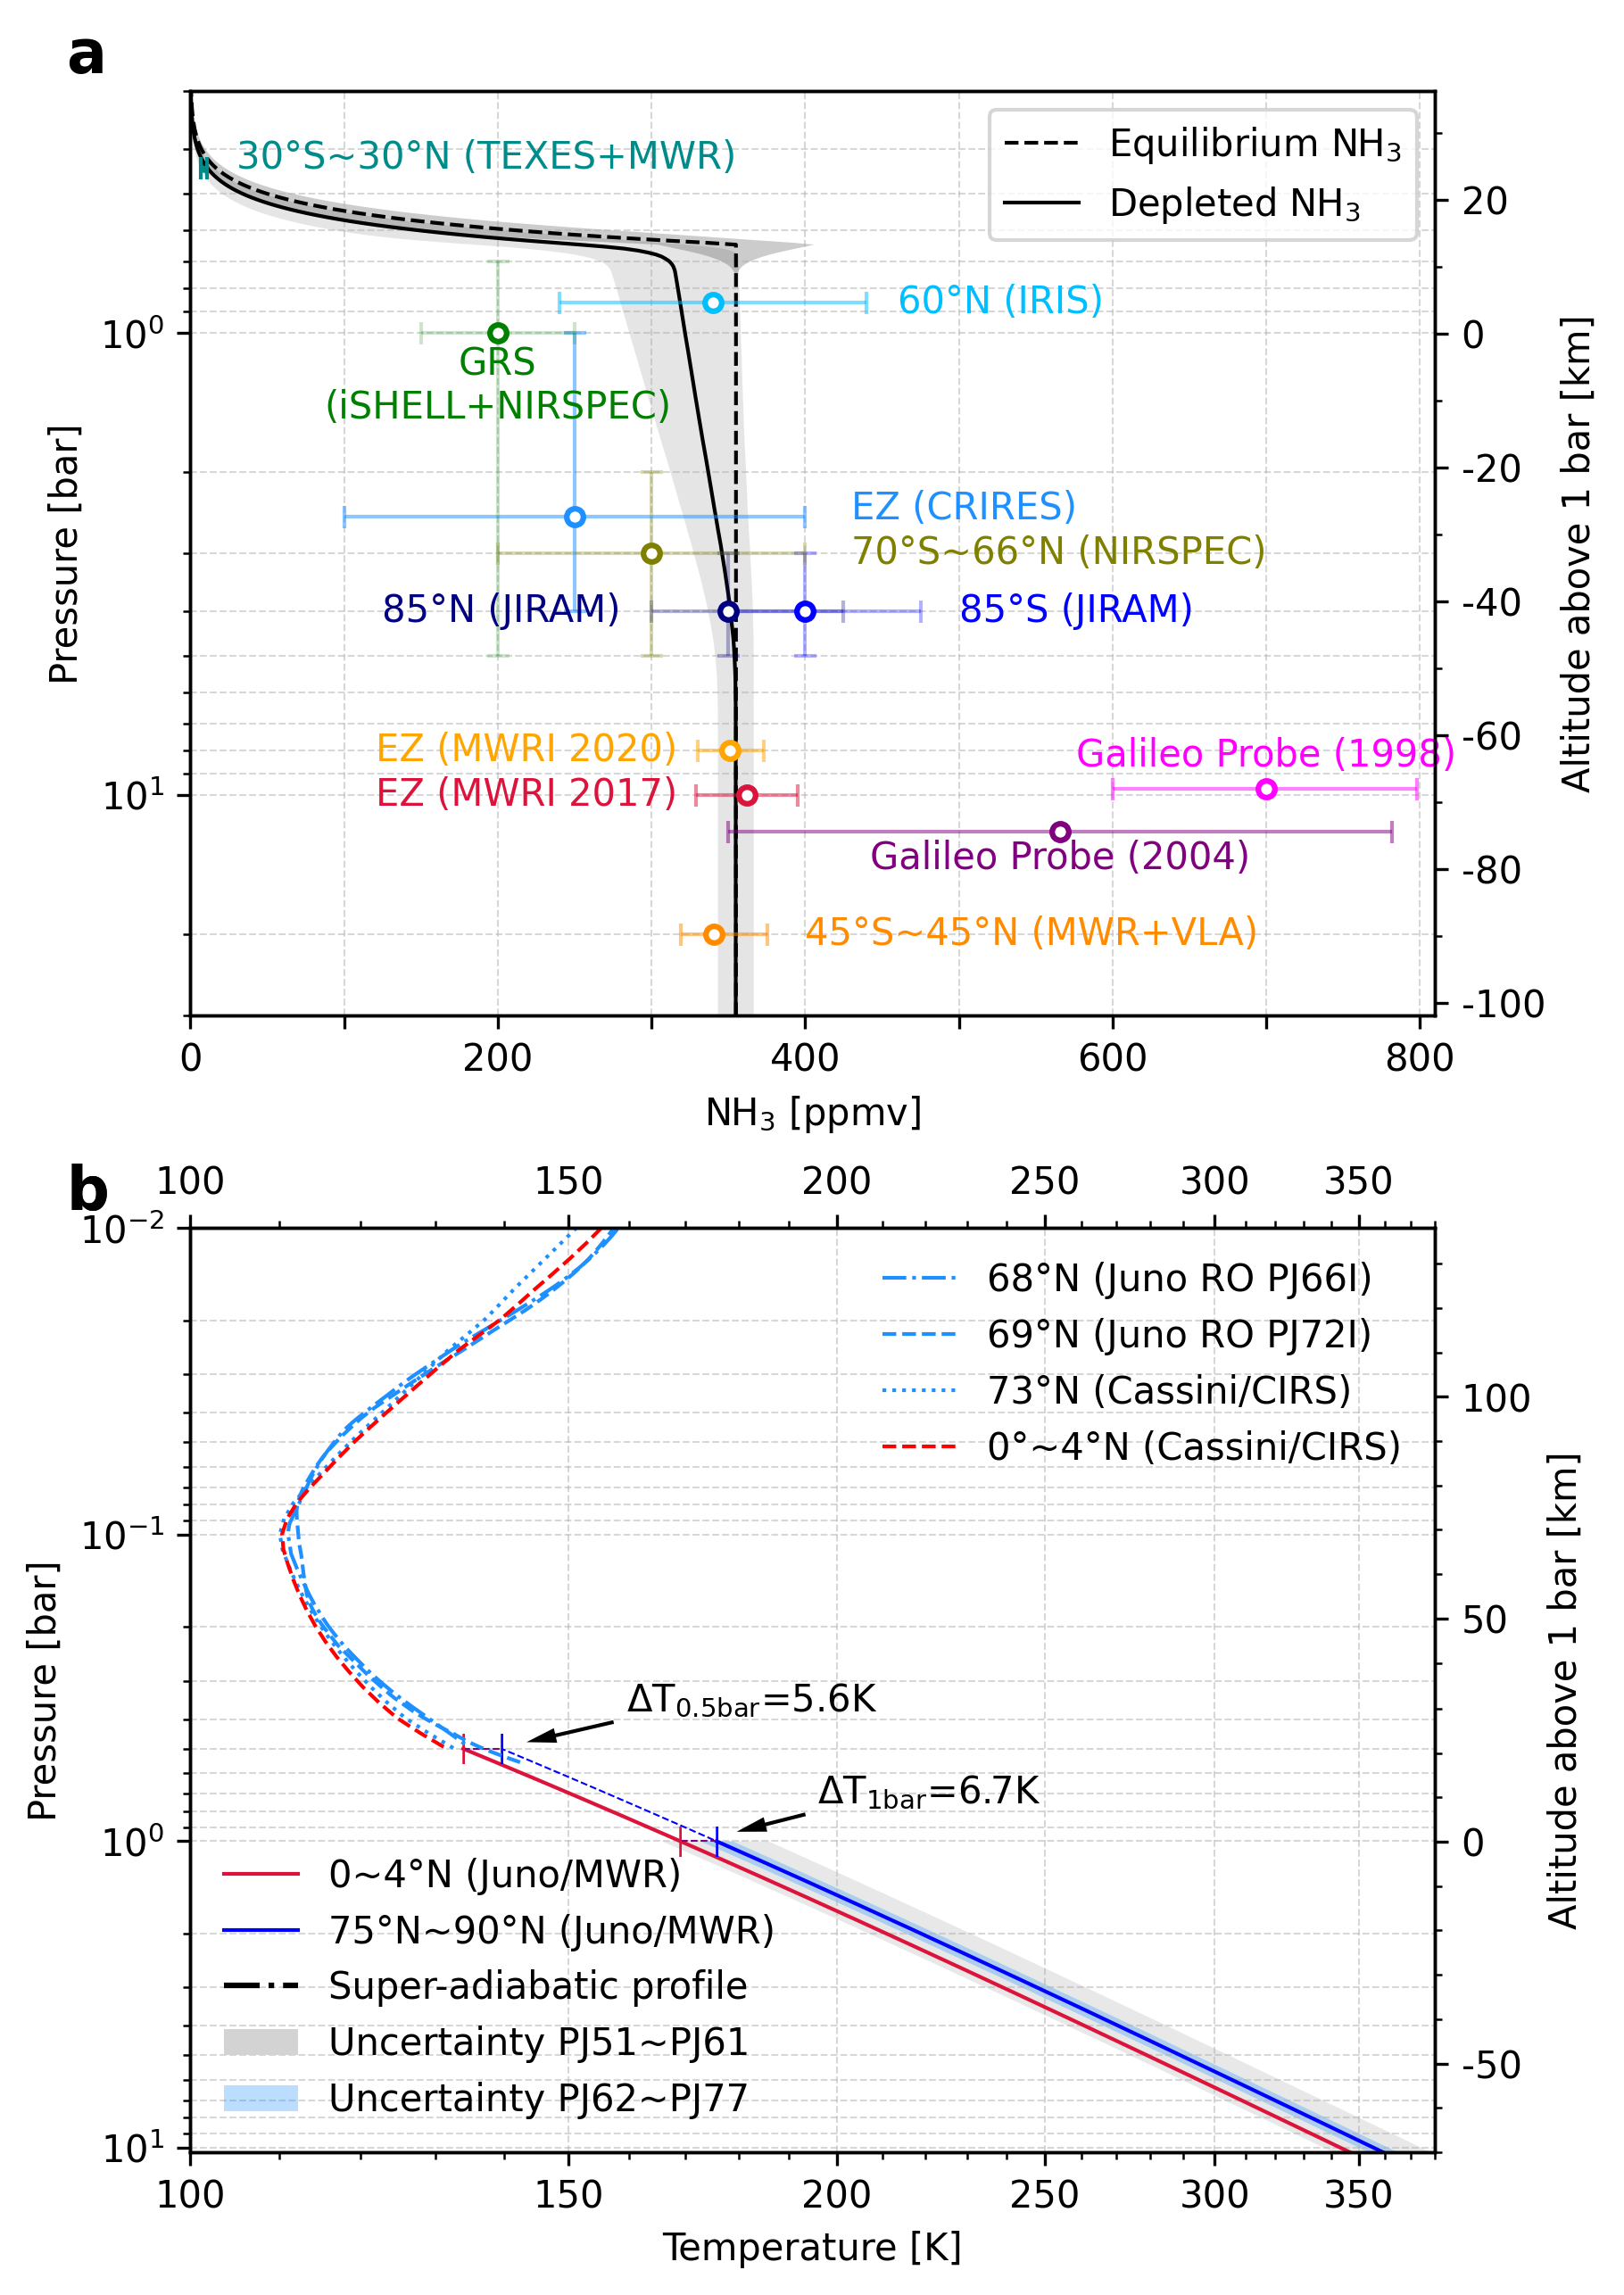

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator

# Open Juno MWR NetCDF file
juno = h5py.File("/home/jihenghu/JHCanoe/build_euler_apative_bg_pseudo/bin/juno_mwr-main.nc", "r")

# Read pressure data and convert units
pressure_bars = juno["press"][0,:,0,0] * 0.00001

# Open the HDF5 file in read mode
filename = "../moist_adiab/reconstruct_atmos_profiles_moist_last5000.h5"
with h5py.File(filename, 'r') as profIN:
    # Extract datasets
    SH_NH3 = profIN['NH3_ppmv'][:, :, :]
    SH_H2O = profIN['H2O_ppmv'][:, :, :]/1000.


filename="../dry_adiab/reconstruct_atmos_profiles_last5000.h5"
with h5py.File(filename, 'r') as profIN:
    # Extract datasets
    SH_NH3_dry = profIN['NH3_ppmv'][:, :, :]
    SH_H2O_dry = profIN['H2O_ppmv'][:, :, :]/1000.

NH3 = np.median(SH_NH3, axis=(0,1))
devNH3 = np.std(SH_NH3, axis=(0,1))


NH3_dry = np.median(SH_NH3_dry, axis=(0,1))
devNH3_dry = np.std(SH_NH3_dry, axis=(0,1))


# from matplotlib.gridspec import GridSpec
# fig = plt.figure(figsize=(7, 12), dpi=300)
# gs = GridSpec(1, 2, width_ratios=[3, 2], wspace=0.2)
# ax1 = fig.add_subplot(gs[0, 0])
# ax2 = fig.add_subplot(gs[0, 1])
fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(6, 10), dpi=300, gridspec_kw={'height_ratios': [1, 1]})
fig.subplots_adjust(hspace=0.23)


ax1.plot(NH3, pressure_bars,'k--', linewidth=1,label=r"NP (equilibrium NH$_3$)")
ax1.fill_betweenx(pressure_bars, NH3 - devNH3, NH3 + devNH3, color='k', alpha=0.2, linewidth=0)

ax1.plot(NH3_dry, pressure_bars, 'k-',linewidth=1, label=r"NP (depleted NH$_3$)")
ax1.fill_betweenx(pressure_bars, NH3_dry - devNH3_dry, NH3_dry + devNH3_dry, color='k', alpha=0.1, linewidth=0)

# ax1.set_xlabel(r'Mixing ratio [ppm]')
ax1.set_ylabel('Pressure [bar]')  # Units in bar
# ax1.set_title('Temperature Profiles of NH3 and H2O')
# ax1.legend()
# ax1.grid()

# Set y-axis to logarithmic scale
ax1.set_yscale('log')
# ax1.set_xscale('log')
ax1.set_xlabel(r'NH$_3$ [ppmv]')

# Set y-limits
ax1.set_ylim(0.3, 30)  # Inverted to match log scale
ax1.set_xlim(0,810)  # Inverted to match log scale
ax1.set_xticks([0,100,200,300,400,500,600,700,800])

# ax1.set_xticklabels(['0','100','200','300','400','500','','700'])
ax1.set_xticklabels(['0','','200','','400','','600','','800'])
ax1.invert_yaxis()  # Invert y-axis for atmospheric profiles






alpha= 0.5
fontsize=10
# li 2020
ax1.errorbar( 351, 8,xerr=[[21], [22]], fmt='', color='orange', ecolor='orange', capsize=3, linewidth=1,alpha=alpha, label= "EZ (Li, 2020)")
ax1.text( 317, 8, "EZ (MWRI 2020)", ha="right", va="center" , color='orange', fontsize=fontsize)

# li 2017
ax1.errorbar( 362, 10,xerr=[[33], [33]], fmt='', color='crimson', ecolor='crimson', capsize=3, linewidth=1, alpha=alpha, label="EZ (Li, 2017)")
ax1.text( 317, 10, "EZ (MWRI 2017)", ha="right" , va="center", color='crimson', fontsize=fontsize)

# de pater 2016 
# ax1.plot( 570, 8, marker='o',  linestyle="", color='orange', label="EZ (de Pater, 2016)")
# ax1.text( 570, 6.5, "EZ (de Pater, 2016)", ha="center", va="center" , color='orange')

# grs galileo probe
ax1.errorbar( 566, 12,xerr=[[216], [216]], fmt='', color='purple', ecolor='purple', capsize=3, linewidth=1,alpha=alpha, label="Galileo Probe(Wong, 2004)")
ax1.text(566, 12.5, "Galileo Probe (2004)", ha="center",   va="top", color='purple', fontsize=fontsize)

# grs galileo probe
ax1.errorbar( 700, 9.7,xerr=[[100], [98]], fmt='', color='magenta', ecolor='magenta', capsize=3, linewidth=1,alpha=alpha, label="Galileo Probe(Folkner, 1998)")
ax1.text(700, 9, "Galileo Probe (1998)", ha="center" , va="bottom", color='magenta', fontsize=fontsize)

# Moeckel
ax1.errorbar( 340.5, 20,xerr=[[21.2], [34.8]], fmt='', color='darkorange', ecolor='darkorange', capsize=3, linewidth=1, alpha=alpha,label="45°S~45°N(Moeckel, 2023)")
ax1.text(400, 20, "45°S~45°N (MWR+VLA)", ha="left", va="center", color='darkorange', fontsize=fontsize)

# Grassi
ax1.errorbar( 350, 4,xerr=[[50], [75]],yerr=[[1], [1]], fmt='', color='navy', ecolor='navy', capsize=3, linewidth=1,alpha=0.3, label="85°N (Grassi, 2020)")
ax1.text(280, 4, "85°N (JIRAM)", va="center" , ha="right", color='navy', fontsize=fontsize)

ax1.errorbar( 400, 4,xerr=[[50], [75]],yerr=[[1], [1]], fmt='', color='b', ecolor='b', capsize=3, linewidth=1, alpha=0.3, label="85°S (Grassi, 2020)")
ax1.text(500, 4, "85°S (JIRAM)", ha="left" , va="center", color='b', fontsize=fontsize)

# Bjoraker
ax1.errorbar( 300,3,xerr=[[100], [100]],yerr=[[1], [2]], fmt='', color='olive', ecolor='olive', capsize=3, linewidth=1,alpha=0.3, label= "70°S~66°N(Bjoraker, 2022)")
ax1.text(430, 3, "70°S~66°N (NIRSPEC)", ha="left" , va="center", color='olive', fontsize=fontsize)


# Giles
ax1.errorbar( 250, 2.5,xerr=[[150], [150]],yerr=[[1.5], [1.5]], fmt='', color='dodgerblue', ecolor='dodgerblue', capsize=3, linewidth=1,alpha=alpha, label="EZ (Giles, 2017)")
ax1.text(430, 2.4, "EZ (CRIRES)", ha="left" , va="center", color='dodgerblue', fontsize=fontsize)


ax1.errorbar( 8.8, 0.44,xerr=[[2], [2]], fmt='', color='darkcyan', ecolor='darkcyan', capsize=3, linewidth=1,alpha=1, label="30°S~30°N (Fletcher, 2020)")
ax1.text(30, 0.44, "30°S~30°N (TEXES+MWR)",  ha="left", color='darkcyan', fontsize=fontsize)

ax1.errorbar( 340, 0.86,xerr=[[100], [100]], fmt='', color='deepskyblue', ecolor='deepskyblue', capsize=3, linewidth=1,alpha=alpha, label="60°N (Fletcher, 2017)")
ax1.text(460, 0.86, "60°N (IRIS)", ha="left", va="center",color='deepskyblue', fontsize=fontsize)

# grs galileo probe
ax1.errorbar( 200, 1,xerr=[[50], [50]],yerr=[[0.3], [4]], fmt='', color='g', ecolor='g', capsize=3, linewidth=1,alpha=0.2, label="GRS (Bjoraker, 2018)")
ax1.text(200, 1.3, "GRS\n(iSHELL+NIRSPEC)", ha="center" , va="center", color='g', fontsize=fontsize)



##############333333333333
msize=20
lw=1.5
clr='white'
ax1.scatter( 351, 8,edgecolor='orange', label= "EZ (Li, 2020)",     s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 362, 10, edgecolor='crimson',label="EZ (Li, 2017)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 566, 12, edgecolor='purple', label="Galileo Probe(Wong, 2004)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 700, 9.7, edgecolor='magenta',  label="Galileo Probe(Folkner, 1998)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 340.5, 20, edgecolor='darkorange',label="45°S~45°N(Moeckel, 2023)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 350, 4, edgecolor='navy',  label="85°N (Grassi, 2020)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 400, 4, edgecolor='b',  label="85°S (Grassi, 2020)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 300,3, edgecolor='olive',  label= "70°S~66°N(Bjoraker, 2022)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 250, 2.5, edgecolor='dodgerblue',   label="EZ (Giles, 2017)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 8.8, 0.44,color='darkcyan', label="30°S~30°N (Fletcher, 2020)",    s=10, marker=".")
ax1.scatter( 340, 0.86, edgecolor='deepskyblue', label="60°N (Fletcher, 2017)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 200, 1, edgecolor='g', label="GRS (Bjoraker, 2018)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)



ax1.text(-0.1, 1.07, "a", fontsize=16, fontweight='bold', va='top', ha='left',transform=ax1.transAxes)
# ax2.text(-0.18, 1.07, "b", fontsize=16, fontweight='bold', va='top', ha='left',transform=ax2.transAxes)
ax2.text(-0.1, 1.07, "b", fontsize=16, fontweight='bold', va='top', ha='left',transform=ax2.transAxes)


axlegend=ax1.twiny()
axlegend.set_xticks([])
axlegend.plot([], [], 'k--', label=r"Equilibrium NH$_3$", linewidth=1)
axlegend.plot([], [], 'k-', label=r"Depleted NH$_3$", linewidth=1)

axlegend.legend(loc="upper right", fontsize=10)
# ax1.legend(loc="upper right", fontsize=8)

# ==========


ax2.text(-0.1, 1.07, "b", fontsize=16, fontweight='bold', va='top', ha='left',transform=ax2.transAxes)

path="/home/jihenghu/JHCanoe/build_euler_apative_bg/bin"

# Open Juno MWR NetCDF file
juno = h5py.File(f"{path}/juno_mwr_dry_uniform_EZ-main.nc", "r")
pressure_bars = juno["press"][0,:,0,0] * 0.00001


# Open profile HDF5 file
profile = h5py.File(f"{path}/juno_mwr_dry_uniform_EZ-main.nc", "r")
Tropical = profile["temp"][0,:, 0, 0]

path="../dry_adiab/"

# profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP-main.nc", "r")
profile2 = h5py.File(f"{path}/juno_mwr_dryadiab_depletedNH3-main.nc", "r")
Tnp = profile2["temp"][0,:, 0, 0]

profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP-10-main.nc", "r")
Tnp_10 = profile2["temp"][0,:, 0, 0]
profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP+10-main.nc", "r")
Tnp10 = profile2["temp"][0,:, 0, 0]

profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP-3-main.nc", "r")
Tnp_3 = profile2["temp"][0,:, 0, 0]
profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP+3-main.nc", "r")
Tnp3 = profile2["temp"][0,:, 0, 0]

mask = pressure_bars >= 0.498

# Plot the curves with masked data
ax2.plot(Tropical[mask], pressure_bars[mask], label='0~4°N (Juno/MWR)', color='crimson', alpha=1, linewidth=1)

mask = pressure_bars >= 0.998
ax2.plot(Tnp[mask], pressure_bars[mask], label='75°N~90°N (Juno/MWR)', color='blue', alpha=1, linewidth=1)

# Masked fill_betweenx for the shaded regions
ax2.fill_betweenx(pressure_bars[mask], Tnp_10[mask], Tnp10[mask], color='lightgray', alpha=0.5, linewidth=0)
ax2.fill_betweenx(pressure_bars[mask], Tnp_3[mask], Tnp3[mask], color='dodgerblue', alpha=0.3, linewidth=0)

mask = (pressure_bars >= 0.498) & (pressure_bars <= 0.998)
ax2.plot(Tnp[mask], pressure_bars[mask], 'b--', alpha=1, linewidth=0.5)

ax2.plot([], [], 'k-.', label='Super-adiabatic profile', linewidth=1.5)

# Label the primary axes
ax2.set_xlabel('Temperature [K]')
ax2.set_ylabel('Pressure [bar]')  # Units in bar
# ax1.set_title('Temperature Profiles of NH3 and H2O')
# ax1.yaxis.set_label_coords(-0.1, 1.)  # Adjust the x and y values to move label position

ax2.set_yscale('log')
ax2.set_xscale('log')


ax2.set_ylim(0.01, 30)  # Inverted to match log scale
ax2.set_xlim(100, 380)  # Inverted to match log scale
ax2.invert_yaxis()  # Invert y-axis for atmospheric profiles
ax2.set_yticks([0.01,0.1,0.5,1,2,3])
ax2.set_yticklabels([0.01,0.1,0.5,1.0,2.0,3.0])

xminor=np.arange(100,390,10)
ax2.xaxis.set_minor_locator(FixedLocator(xminor))
ax2.set_xticks([100,150,200,250,300,350])
ax2.set_xticklabels([100,150,200,250,300,350])
ax2.tick_params(axis='x', which='minor',top =True, labelcolor='white', labelsize=0)


import matplotlib.patches as patches
rect1 = patches.Rectangle((-999, 0.9), 19, 0.15, linewidth=0, facecolor='lightgray', alpha=1, label="Uncertainty PJ51~PJ61")
rect2 = patches.Rectangle((-999, 0.9), 19, 0.15, linewidth=0, facecolor='dodgerblue', alpha=0.3, label="Uncertainty PJ62~PJ77")
ax2.add_patch(rect1)
ax2.add_patch(rect2)
# ax2.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.3, 0.91))

    
idx = np.argmin(np.abs(pressure_bars - 0.5))
temp_difference = Tnp[idx] - Tropical[idx]
ax2.annotate(rf"$\Delta$T$_\text{{0.5bar}}$={temp_difference:0.1f}K", xy=(Tnp[idx]+3, 0.48), xytext=(Tnp[idx]+20, 0.4),
    arrowprops=dict(facecolor='k',  shrink=0.05, width=1, headwidth=4, headlength=8, edgecolor='none'),
    ha='left', va='bottom', color='k', fontsize=10)

idx = np.argmin(np.abs(pressure_bars - 1))
temp_difference = Tnp[idx] - Tropical[idx]
ax2.annotate(rf"$\Delta$T$_\text{{1bar}}$={temp_difference:0.1f}K", xy=(Tnp[idx]+3, 0.94), xytext=(Tnp[idx]+20, 0.8),
    arrowprops=dict(facecolor='k',  shrink=0.05, width=1, headwidth=4, headlength=8, edgecolor='none'),
    ha='left', va='bottom', color='k', fontsize=10)


idx = np.argmin(np.abs(pressure_bars - 0.5))
ax2.text(Tropical[idx], 0.5, "|", color='crimson', ha="center", va="center" , fontsize=8)
ax2.text(Tnp[idx], 0.5, "|", color='b', ha="center", va="center" , fontsize=8)
ax2.plot([Tropical[idx], Tnp[idx]],[0.5,0.5], color='purple', linestyle='--', linewidth=0.5)


idx = np.argmin(np.abs(pressure_bars - 1))
ax2.text(Tropical[idx], 1, "|", color='crimson', ha="center", va="center" , fontsize=8)
ax2.text(Tnp[idx], 1, "|", color='b', ha="center", va="center" , fontsize=8)
ax2.plot([Tropical[idx], Tnp[idx]],[1,1], color='purple', linestyle='--', linewidth=0.5)


ax2.legend(frameon=False,loc='lower left', fontsize=10)





ax3=ax2.twiny()
ax3.set_yscale('log')
ax3.set_ylim(0.01, 10.37)  # Inverted to match log scale
# ax2.set_yticks([0.01,0.1])
ax3.invert_yaxis() 

ax3.set_xscale('log')
ax3.set_xlim(100,380)  # Inverted to match log scale


# set xminorticks to empty
xminor=np.arange(100,390,10)
ax3.xaxis.set_minor_locator(FixedLocator(xminor))
ax3.set_xticks([100,150,200,250,300,350])
ax3.set_xticklabels([100,150,200,250,300,350])
ax3.tick_params(axis='x', which='minor',top =True, labelcolor='white', labelsize=0)
# ax3.set_xlabel('Temperature [K]')

import pandas as pd
from matplotlib.gridspec import GridSpec

# Load the CSV file

data = pd.read_csv('PJ66I.csv', header=None)
press = data[0]  # First column
pj66 = data[1]   # Second column
ax3.plot(pj66, press, 'dodgerblue', linestyle='-.', alpha=1, linewidth=1, label="68°N (Juno RO PJ66I)", )

# data = pd.read_csv('PJ54E_1.csv', header=None)
# press = data[0]  # First column
# pj54 = data[1]   # Second column
# ax3.plot(pj54, press, color="orange", linestyle='--',alpha=1, linewidth=1, label="15°N (Juno RO PJ54E_old)")
# data = pd.read_csv('PJ54E.csv', header=None)
# press = data[0]  # First column
# pj54 = data[1]   # Second column
# ax3.plot(pj54, press, color="orange", linestyle='-',alpha=1, linewidth=1, label="15°N (Juno RO PJ54E_new)")

data = pd.read_csv('PJ72I.csv', header=None)
press = data[0]  # First column
pj72 = data[1]   # Second column
ax3.plot(pj72, press, color="dodgerblue", linestyle='--',alpha=1, linewidth=1, label="69°N (Juno RO PJ72I)")



read_data = np.loadtxt('cassini_voyager_temp.txt', skiprows=1)
cassini_75 = read_data[:, 0]
# voyager_75 = read_data[:, 1]
cassini_ez = read_data[:, 2]
voyager_ez = read_data[:, 3]
pressure_unique = read_data[:, 4]

# Plot Cassini and Voyager data
ax3.plot(cassini_75, pressure_unique*1E-3, color='dodgerblue', linestyle=':', alpha=1, linewidth=1, label="73°N (Cassini/CIRS)")
ax3.plot(cassini_ez, pressure_unique*1E-3, color='red', linestyle='--', alpha=1, linewidth=1, label="0°~4°N (Cassini/CIRS)")
# ax3.plot(voyager_ez, pressure_unique*1E-3, color='magenta', linestyle='--', alpha=1, linewidth=1, label="0°~4°N (Voyager IRIS)")


ax3.legend(frameon=False,loc='upper right', fontsize=10)




################################3

# read 'x1' from build/bin/juno_mwr-main.nc
with h5py.File("/data/jihenghu/juno-mwr-deconv-research/13.cpc.grid.retrv/build/bin/juno_mwr-main.nc", "r") as f:
    x1 = f["x1"][:]*1E-3 # km
xticks=[-70,-60,-50,-40,-30,-20,-10,0,10,20,30,40,50,60,70,80,90,100,110,120,130]
pinx = np.interp(xticks, x1, pressure_bars)
print(pinx)

axht = ax2.twinx()
# axht.invert_yaxis()  # Invert y-axis to match pressure scale
axht.set_ylim( 10.37,0.01)
axht.set_yscale('log')

axht.plot(x1, pressure_bars, color='k', linewidth=0)

axht.set_yticks(pinx[2::5])      # Align ticks to pressure levels
axht.set_yticklabels(xticks[2::5])   # Show height at each pressure
axht.set_ylabel('Altitude above 1 bar [km]')

from matplotlib.ticker import FixedLocator
axht.yaxis.set_minor_locator(FixedLocator(pinx))
axht.tick_params(axis='both', which='major',top =True, labelsize=10)
axht.tick_params(axis='both', which='minor',top =True, labelcolor='white', labelsize=0)



xticks=[-100,-90,-80,-70,-60,-50,-40,-30,-20,-10,0,10,20,30]
pinx = np.interp(xticks, x1, pressure_bars)
print(pinx)

axht = ax1.twinx()
# axht.invert_yaxis()  # Invert y-axis to match pressure scale
axht.set_ylim(30,0.3)
axht.set_yscale('log')

axht.plot(x1, pressure_bars, color='k', linewidth=0)

axht.set_yticks(pinx[::2])      # Align ticks to pressure levels
axht.set_yticklabels(xticks[::2])   # Show height at each pressure
axht.set_ylabel('Altitude above 1 bar [km]')

from matplotlib.ticker import FixedLocator
axht.yaxis.set_minor_locator(FixedLocator(pinx))
axht.tick_params(axis='both', which='major',top =True, labelsize=10)
axht.tick_params(axis='both', which='minor',top =True, labelcolor='white', labelsize=0)

for ax in [ax1, ax2]:
    ax.grid(axis='both', which='major', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.grid(axis='y', which='both', linestyle='--', linewidth=0.5, alpha=0.5)
     
plt.show()


['39.31', '28.17', '20.18', '14.46', '10.36', '7.43', '5.32', '3.81', '2.73', '1.96', '1.40', '1.00', '0.72', '0.52', '0.37', '0.26', '0.19', '0.13', '0.10', '0.07', '0.05', '0.04', '0.03', '0.02', '0.01']


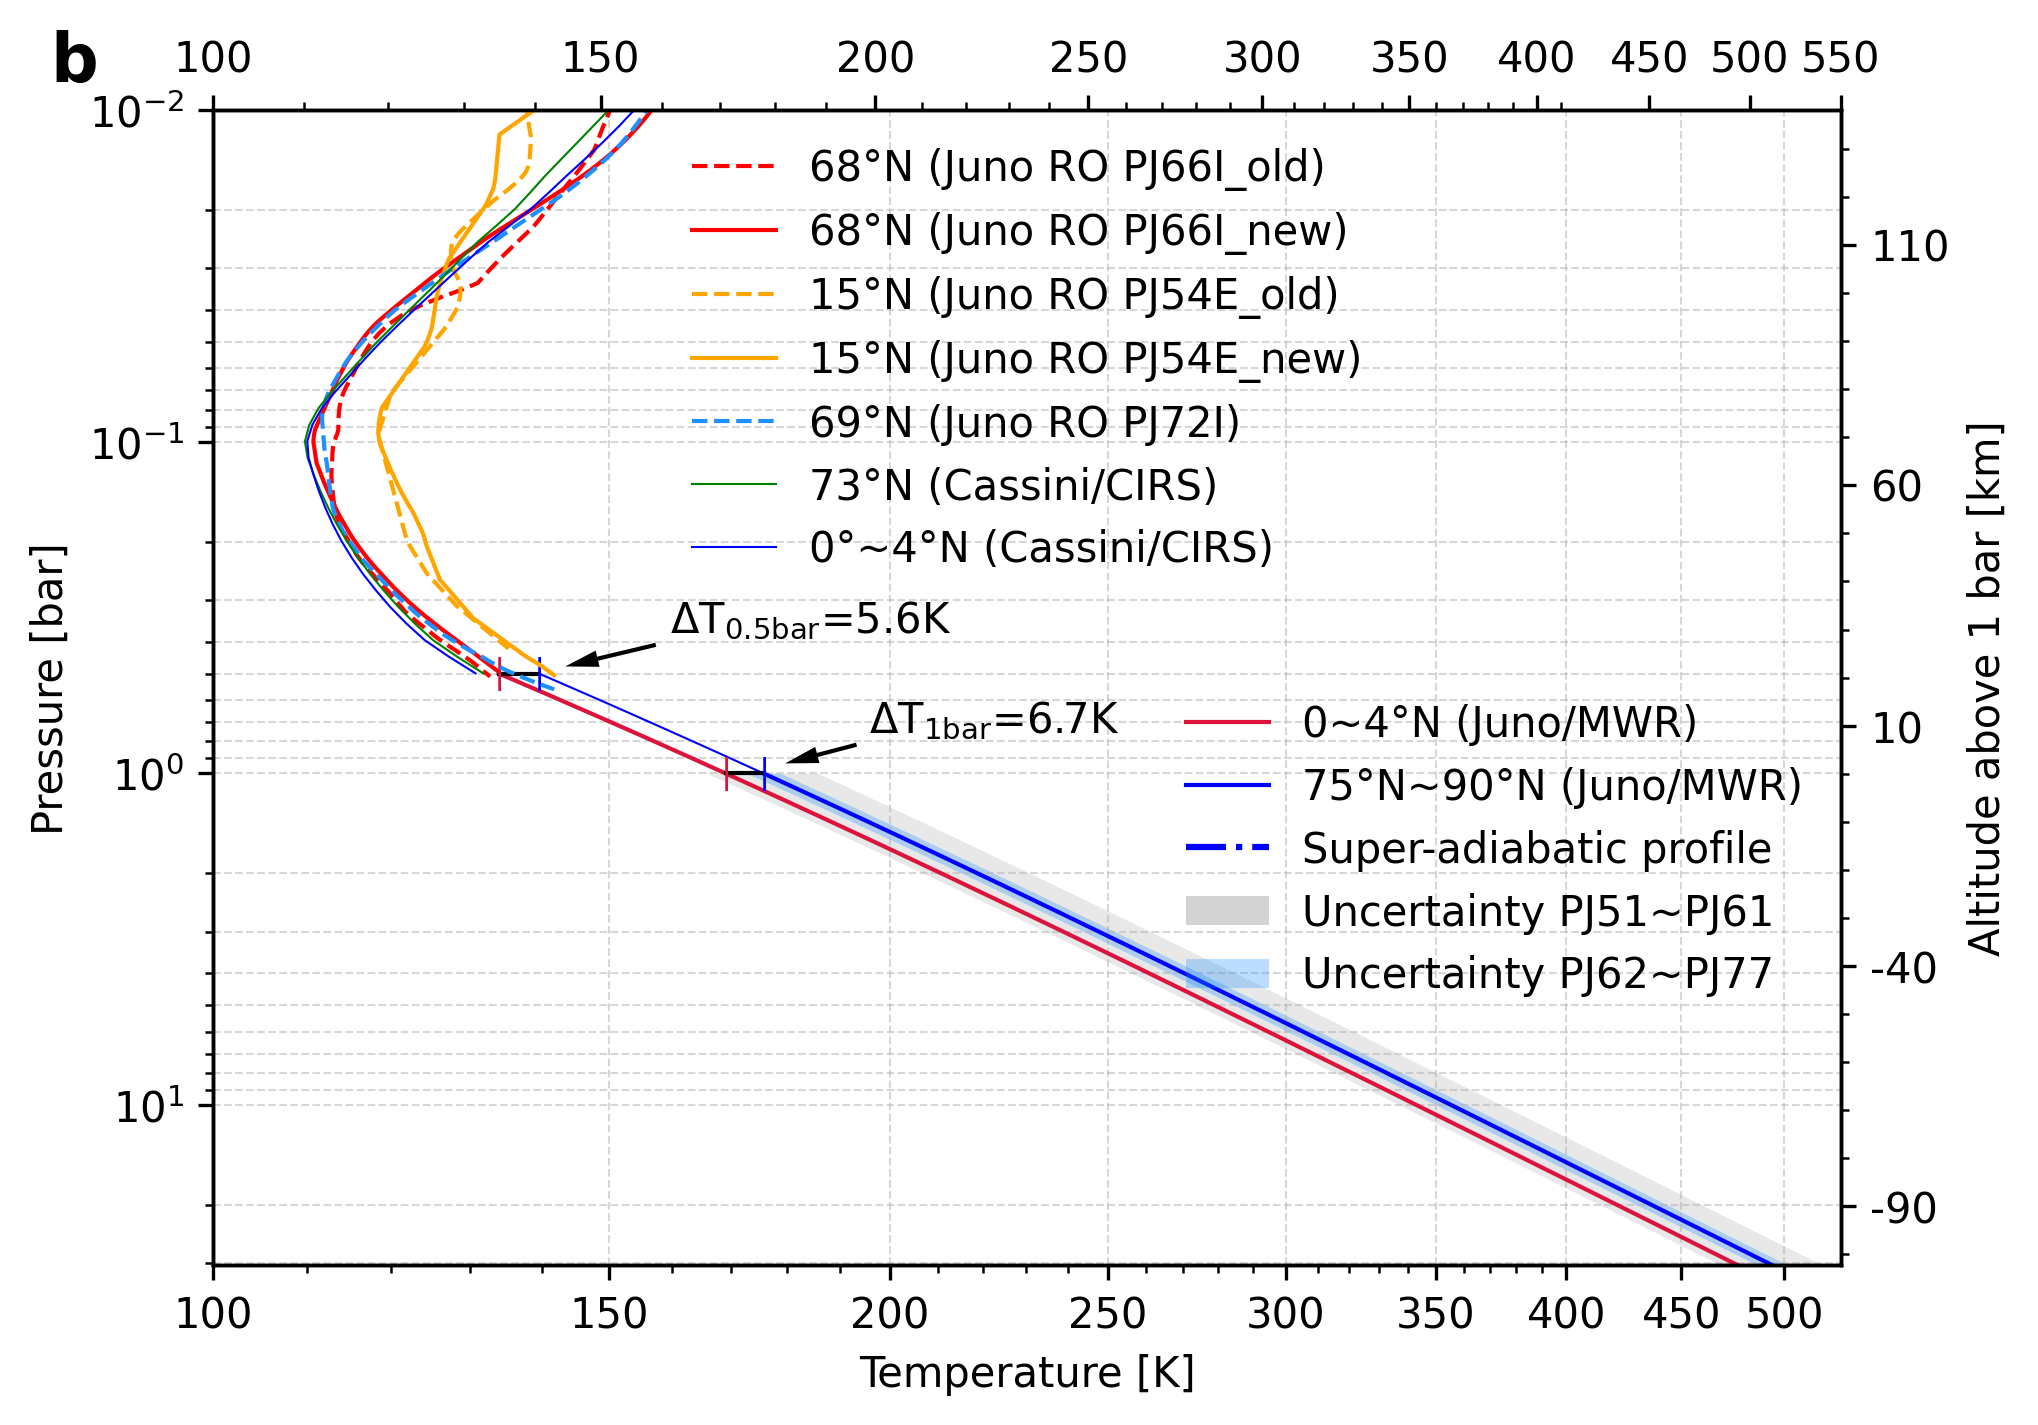

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator

# Open Juno MWR NetCDF file
juno = h5py.File("/home/jihenghu/JHCanoe/build_euler_apative_bg_pseudo/bin/juno_mwr-main.nc", "r")

# Read pressure data and convert units
pressure_bars = juno["press"][0,:,0,0] * 0.00001

fig, ax2 = plt.subplots(1, 1, figsize=(7, 5), dpi=300)

ax2.text(-0.1, 1.07, "b", fontsize=16, fontweight='bold', va='top', ha='left',transform=ax2.transAxes)

path="/home/jihenghu/JHCanoe/build_euler_apative_bg/bin"

# Open Juno MWR NetCDF file
juno = h5py.File(f"{path}/juno_mwr_dry_uniform_EZ-main.nc", "r")
pressure_bars = juno["press"][0,:,0,0] * 0.00001


# Open profile HDF5 file
profile = h5py.File(f"{path}/juno_mwr_dry_uniform_EZ-main.nc", "r")
Tropical = profile["temp"][0,:, 0, 0]

path="../dry_adiab/"

# profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP-main.nc", "r")
profile2 = h5py.File(f"{path}/juno_mwr_dryadiab_depletedNH3-main.nc", "r")
Tnp = profile2["temp"][0,:, 0, 0]

profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP-10-main.nc", "r")
Tnp_10 = profile2["temp"][0,:, 0, 0]
profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP+10-main.nc", "r")
Tnp10 = profile2["temp"][0,:, 0, 0]

profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP-3-main.nc", "r")
Tnp_3 = profile2["temp"][0,:, 0, 0]
profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP+3-main.nc", "r")
Tnp3 = profile2["temp"][0,:, 0, 0]

mask = pressure_bars >= 0.498

# Plot the curves with masked data
ax2.plot(Tropical[mask], pressure_bars[mask], label='0~4°N (Juno/MWR)', color='crimson', alpha=1, linewidth=1)

mask = pressure_bars >= 0.998
ax2.plot(Tnp[mask], pressure_bars[mask], label='75°N~90°N (Juno/MWR)', color='blue', alpha=1, linewidth=1)

# Masked fill_betweenx for the shaded regions
ax2.fill_betweenx(pressure_bars[mask], Tnp_10[mask], Tnp10[mask], color='lightgray', alpha=0.5, linewidth=0)
ax2.fill_betweenx(pressure_bars[mask], Tnp_3[mask], Tnp3[mask], color='dodgerblue', alpha=0.3, linewidth=0)

mask = (pressure_bars >= 0.498) & (pressure_bars <= 0.998)
ax2.plot(Tnp[mask], pressure_bars[mask], 'b-', alpha=1, linewidth=0.5)

ax2.plot([], [], 'b-.', label='Super-adiabatic profile', linewidth=1.5)

# Label the primary axes
ax2.set_xlabel('Temperature [K]')
ax2.set_ylabel('Pressure [bar]')  # Units in bar
# ax1.set_title('Temperature Profiles of NH3 and H2O')
# ax1.yaxis.set_label_coords(-0.1, 1.)  # Adjust the x and y values to move label position

ax2.set_yscale('log')
ax2.set_xscale('log')


ax2.set_ylim(0.01, 30)  # Inverted to match log scale
ax2.set_xlim(100, 530)  # Inverted to match log scale
ax2.invert_yaxis()  # Invert y-axis for atmospheric profiles
ax2.set_yticks([0.01,0.1,0.5,1,2,3])
ax2.set_yticklabels([0.01,0.1,0.5,1.0,2.0,3.0])

xminor=np.arange(100,410,10)
ax2.xaxis.set_minor_locator(FixedLocator(xminor))
ax2.set_xticks([100,150,200,250,300,350,400,450,500])
ax2.set_xticklabels([100,150,200,250,300,350,400,450,500])
ax2.tick_params(axis='x', which='minor',top =True, labelcolor='white', labelsize=0)


import matplotlib.patches as patches
rect1 = patches.Rectangle((-999, 0.9), 19, 0.15, linewidth=0, facecolor='lightgray', alpha=1, label="Uncertainty PJ51~PJ61")
rect2 = patches.Rectangle((-999, 0.9), 19, 0.15, linewidth=0, facecolor='dodgerblue', alpha=0.3, label="Uncertainty PJ62~PJ77")
ax2.add_patch(rect1)
ax2.add_patch(rect2)
# ax2.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.3, 0.91))

    
idx = np.argmin(np.abs(pressure_bars - 0.5))
temp_difference = Tnp[idx] - Tropical[idx]
ax2.annotate(rf"$\Delta$T$_\text{{0.5bar}}$={temp_difference:0.1f}K", xy=(Tnp[idx]+3, 0.48), xytext=(Tnp[idx]+20, 0.4),
    arrowprops=dict(facecolor='k',  shrink=0.05, width=1, headwidth=4, headlength=8, edgecolor='none'),
    ha='left', va='bottom', color='k', fontsize=10)

idx = np.argmin(np.abs(pressure_bars - 1))
temp_difference = Tnp[idx] - Tropical[idx]
ax2.annotate(rf"$\Delta$T$_\text{{1bar}}$={temp_difference:0.1f}K", xy=(Tnp[idx]+3, 0.94), xytext=(Tnp[idx]+20, 0.8),
    arrowprops=dict(facecolor='k',  shrink=0.05, width=1, headwidth=4, headlength=8, edgecolor='none'),
    ha='left', va='bottom', color='k', fontsize=10)


idx = np.argmin(np.abs(pressure_bars - 0.5))
ax2.text(Tropical[idx], 0.5, "|", color='crimson', ha="center", va="center" , fontsize=8)
ax2.text(Tnp[idx], 0.5, "|", color='b', ha="center", va="center" , fontsize=8)
ax2.plot([Tropical[idx], Tnp[idx]],[0.5,0.5], color='k', linestyle='-', linewidth=1)


idx = np.argmin(np.abs(pressure_bars - 1))
ax2.text(Tropical[idx], 1, "|", color='crimson', ha="center", va="center" , fontsize=8)
ax2.text(Tnp[idx], 1, "|", color='b', ha="center", va="center" , fontsize=8)
ax2.plot([Tropical[idx], Tnp[idx]],[1,1], color='k', linestyle='-', linewidth=1)


ax2.legend(frameon=False,loc='lower right', fontsize=10, bbox_to_anchor=(1., 0.2))





ax3=ax2.twiny()
ax3.set_yscale('log')
ax3.set_ylim(0.01, 30.37)  # Inverted to match log scale
# ax2.set_yticks([0.01,0.1])
ax3.invert_yaxis() 

ax3.set_xscale('log')
ax3.set_xlim(100,550)  # Inverted to match log scale


# set xminorticks to empty
xminor=np.arange(100,420,10)
ax3.xaxis.set_minor_locator(FixedLocator(xminor))
ax3.set_xticks([100,150,200,250,300,350,400,450,500,550])
ax3.set_xticklabels([100,150,200,250,300,350,400,450,500,550])
ax3.tick_params(axis='x', which='minor',top =True, labelcolor='white', labelsize=0)


import pandas as pd
from matplotlib.gridspec import GridSpec

# Load the CSV file

data = pd.read_csv('PJ66I_1.csv', header=None)
press = data[0]  # First column
pj66 = data[1]   # Second column
ax3.plot(pj66, press, 'r', linestyle='--', alpha=1, linewidth=1, label="68°N (Juno RO PJ66I_old)", )

data = pd.read_csv('PJ66I.csv', header=None)
press = data[0]  # First column
pj66 = data[1]   # Second column
ax3.plot(pj66, press, 'r', linestyle='-', alpha=1, linewidth=1, label="68°N (Juno RO PJ66I_new)", )



data = pd.read_csv('PJ54E_1.csv', header=None)
press = data[0]  # First column
pj54 = data[1]   # Second column
ax3.plot(pj54, press, color="orange", linestyle='--',alpha=1, linewidth=1, label="15°N (Juno RO PJ54E_old)")

data = pd.read_csv('PJ54E.csv', header=None)
press = data[0]  # First column
pj54 = data[1]   # Second column
ax3.plot(pj54, press, color="orange", linestyle='-',alpha=1, linewidth=1, label="15°N (Juno RO PJ54E_new)")



data = pd.read_csv('PJ72I.csv', header=None)
press = data[0]  # First column
pj72 = data[1]   # Second column
ax3.plot(pj72, press, color="dodgerblue", linestyle='--',alpha=1, linewidth=1, label="69°N (Juno RO PJ72I)")

read_data = np.loadtxt('/data/jihenghu/juno-mwr-deconv-research/9.radio_occultation/cassini_voyager_temp.txt', skiprows=1)
cassini_75 = read_data[:, 0]
# voyager_75 = read_data[:, 1]
cassini_ez = read_data[:, 2]
voyager_ez = read_data[:, 3]
pressure_unique = read_data[:, 4]

# Plot Cassini and Voyager data
ax3.plot(cassini_75, pressure_unique*1E-3, color='g', linestyle='-', alpha=1, linewidth=0.5, label="73°N (Cassini/CIRS)")
ax3.plot(cassini_ez, pressure_unique*1E-3, color='b', linestyle='-', alpha=1, linewidth=0.5, label="0°~4°N (Cassini/CIRS)")
# ax3.plot(voyager_ez, pressure_unique*1E-3, color='magenta', linestyle='--', alpha=1, linewidth=1, label="0°~4°N (Voyager IRIS)")


ax3.legend(frameon=False,loc='upper center', fontsize=10)



# read 'x1' from build/bin/juno_mwr-main.nc
with h5py.File("/data/jihenghu/juno-mwr-deconv-research/13.cpc.grid.retrv/build/bin/juno_mwr-main.nc", "r") as f:
    x1 = f["x1"][:]*1E-3 # km
xticks=[-110,-100,-90,-80,-70,-60,-50,-40,-30,-20,-10,0,10,20,30,40,50,60,70,80,90,100,110,120,130]
pinx = np.interp(xticks, x1, pressure_bars)
print([f"{px:.2f}" for px in pinx])

axht = ax2.twinx()
# axht.invert_yaxis()  # Invert y-axis to match pressure scale
axht.set_ylim( 30.37,0.01)
axht.set_yscale('log')

axht.plot(x1, pressure_bars, color='k', linewidth=0)

axht.set_yticks(pinx[2::5])      # Align ticks to pressure levels
axht.set_yticklabels(xticks[2::5])   # Show height at each pressure
axht.set_ylabel('Altitude above 1 bar [km]')

from matplotlib.ticker import FixedLocator
axht.yaxis.set_minor_locator(FixedLocator(pinx))
axht.tick_params(axis='both', which='major',top =True, labelsize=10)
axht.tick_params(axis='both', which='minor',top =True, labelcolor='white', labelsize=0)

ax2.grid(axis='x', which='major', linestyle='--', linewidth=0.5, alpha=0.5)
ax2.grid(axis='y', which='both', linestyle='--', linewidth=0.5, alpha=0.5)
    

# 
plt.show()


[2.81694290e+01 2.01842972e+01 1.44626949e+01 1.03629814e+01
 7.42540455e+00 5.32053655e+00 3.81233199e+00 2.73165513e+00
 1.95731612e+00 1.40247781e+00 1.00491877e+00 7.20055312e-01
 5.15941722e-01 3.69688040e-01 2.62311630e-01 1.87954244e-01
 1.34674907e-01 9.64986040e-02 6.91441396e-02 4.95439976e-02
 3.54998852e-02 2.54368217e-02 1.82263086e-02 1.30597350e-02]


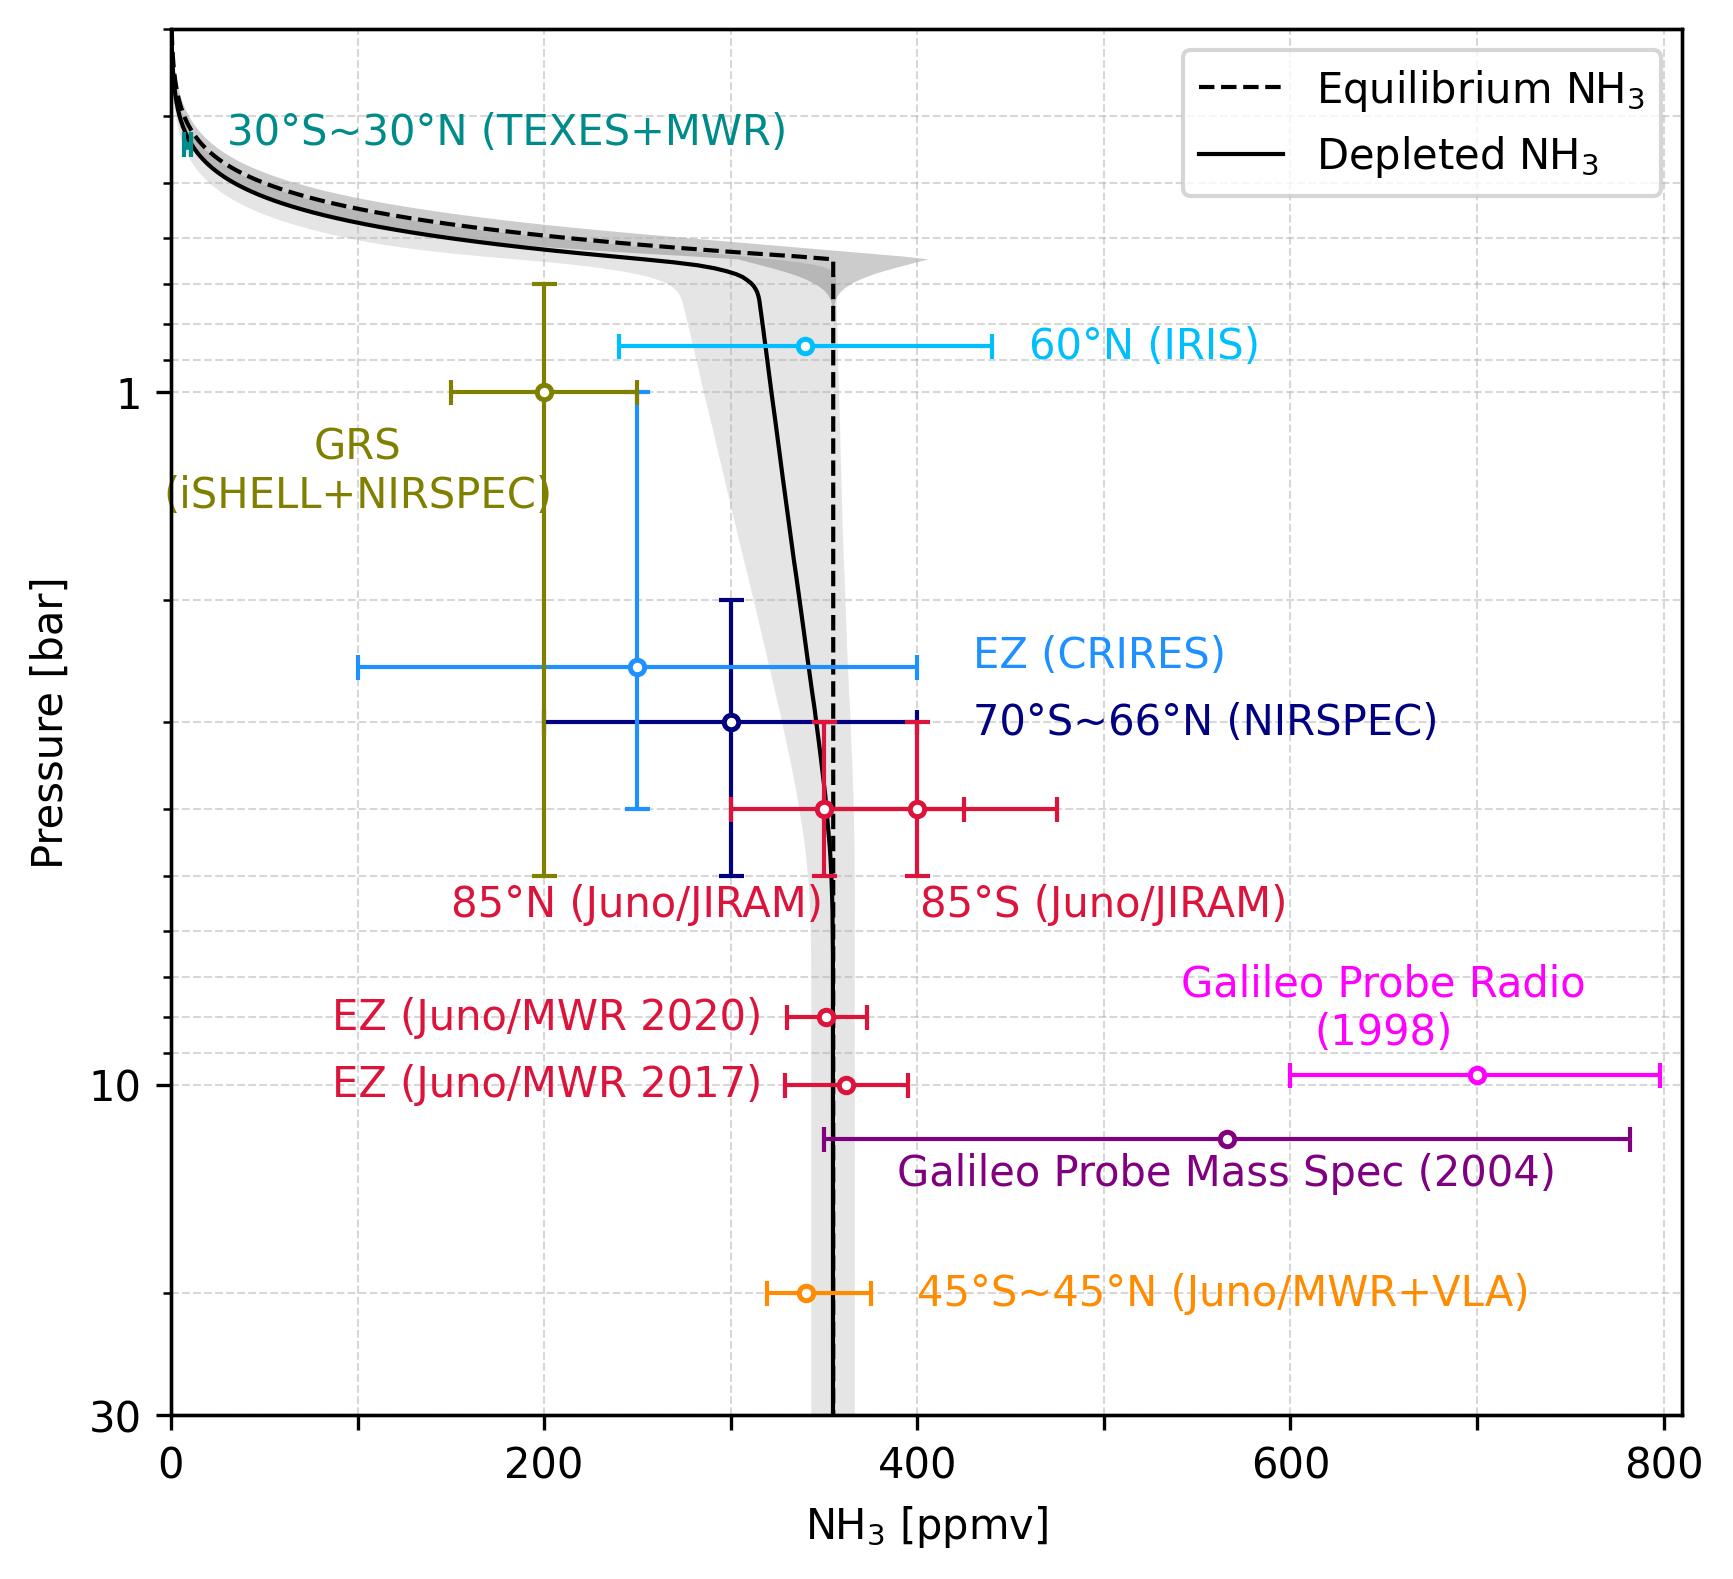

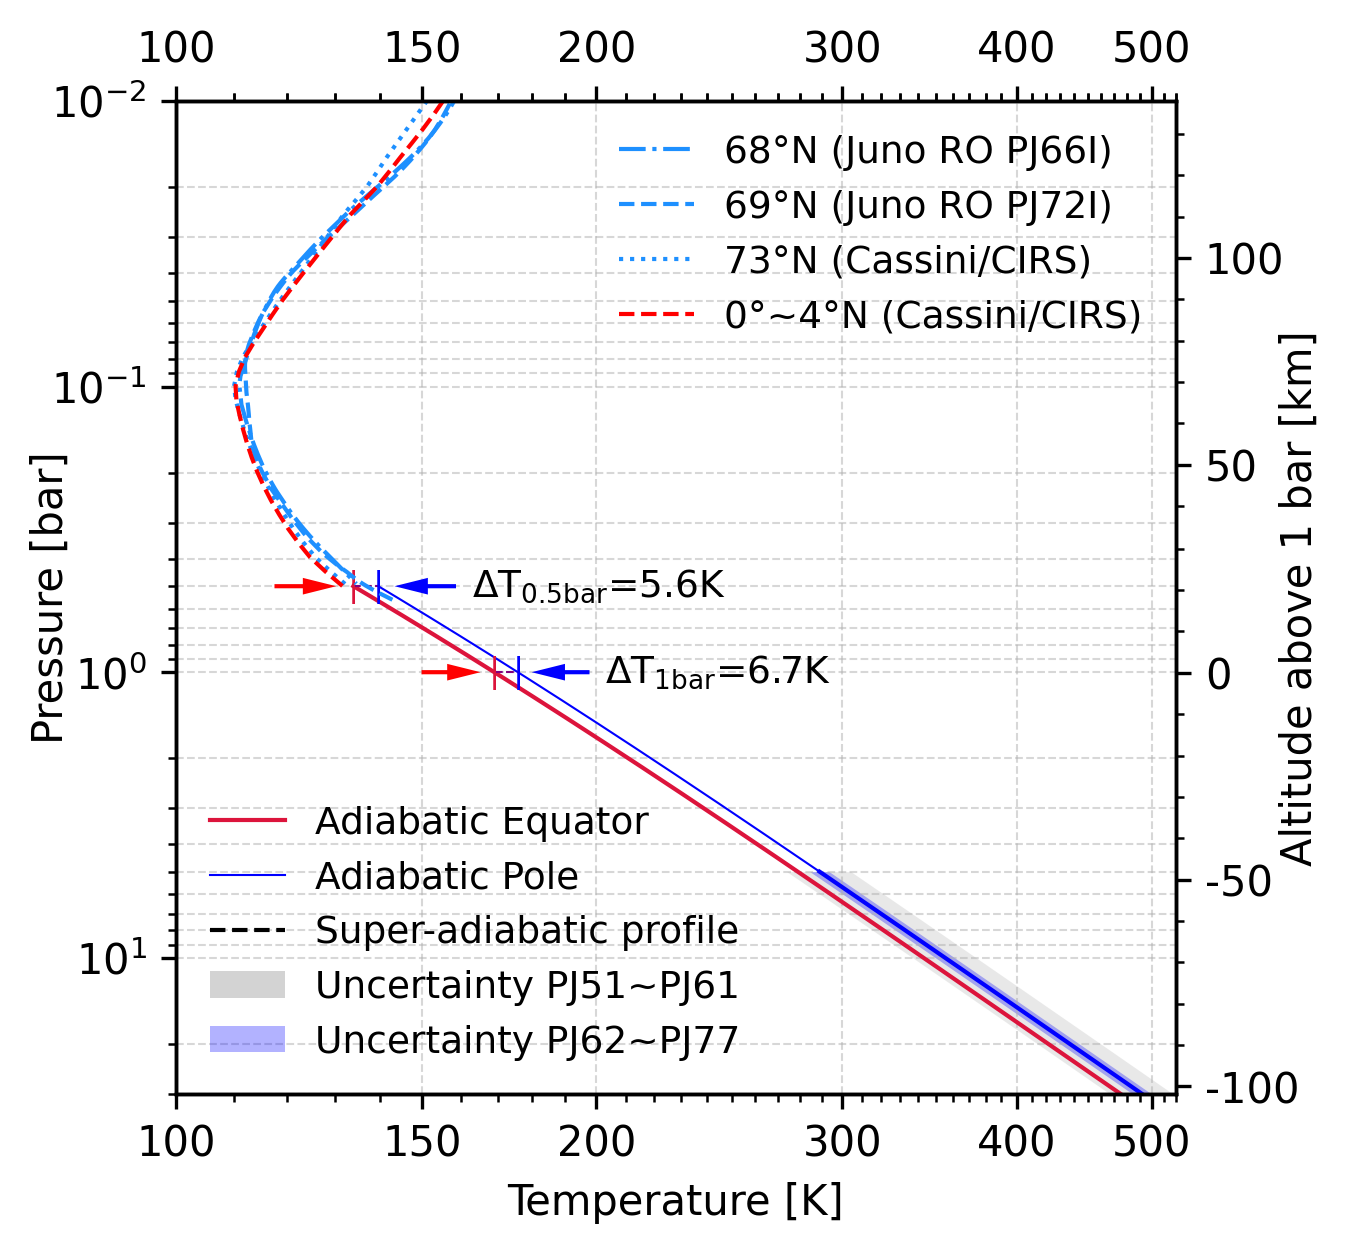

In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator

# Open Juno MWR NetCDF file
juno = h5py.File("/home/jihenghu/JHCanoe/build_euler_apative_bg_pseudo/bin/juno_mwr-main.nc", "r")

# Read pressure data and convert units
pressure_bars = juno["press"][0,:,0,0] * 0.00001

# Open the HDF5 file in read mode
filename = "../moist_adiab/reconstruct_atmos_profiles_moist_last5000.h5"
with h5py.File(filename, 'r') as profIN:
    # Extract datasets
    SH_NH3 = profIN['NH3_ppmv'][:, :, :]
    SH_H2O = profIN['H2O_ppmv'][:, :, :]/1000.


filename="../dry_adiab/reconstruct_atmos_profiles_last5000.h5"
with h5py.File(filename, 'r') as profIN:
    # Extract datasets
    SH_NH3_dry = profIN['NH3_ppmv'][:, :, :]
    SH_H2O_dry = profIN['H2O_ppmv'][:, :, :]/1000.

NH3 = np.median(SH_NH3, axis=(0,1))
devNH3 = np.std(SH_NH3, axis=(0,1))


NH3_dry = np.median(SH_NH3_dry, axis=(0,1))
devNH3_dry = np.std(SH_NH3_dry, axis=(0,1))


# from matplotlib.gridspec import GridSpec
# fig = plt.figure(figsize=(7, 12), dpi=300)
# gs = GridSpec(1, 2, width_ratios=[3, 2], wspace=0.2)
# ax1 = fig.add_subplot(gs[0, 0])
# ax2 = fig.add_subplot(gs[0, 1])
fig, ax1 = plt.subplots(1, 1, figsize=(6.5, 6), dpi=300)
# fig.subplots_adjust(hspace=0.21)


ax1.plot(NH3, pressure_bars,'k--', linewidth=1,label=r"NP (equilibrium NH$_3$)")
ax1.fill_betweenx(pressure_bars, NH3 - devNH3, NH3 + devNH3, color='k', alpha=0.2, linewidth=0)

ax1.plot(NH3_dry, pressure_bars, 'k-',linewidth=1, label=r"NP (depleted NH$_3$)")
ax1.fill_betweenx(pressure_bars, NH3_dry - devNH3_dry, NH3_dry + devNH3_dry, color='k', alpha=0.1, linewidth=0)

# ax1.set_xlabel(r'Mixing ratio [ppm]')
ax1.set_ylabel('Pressure [bar]')  # Units in bar
# ax1.set_title('Temperature Profiles of NH3 and H2O')
# ax1.legend()
ax1.grid()

# Set y-axis to logarithmic scale
ax1.set_yscale('log')
# ax1.set_xscale('log')
ax1.set_xlabel(r'NH$_3$ [ppmv]')

# Set y-limits
ax1.set_ylim(0.3, 30)  # Inverted to match log scale
ax1.set_xlim(0,810)  # Inverted to match log scale
ax1.set_xticks([0,100,200,300,400,500,600,700,800])

ax1.set_yticks([1, 10, 30])  # Inverted to match log scale
ax1.set_yticklabels([1, 10, 30])  # Inverted to match log scale
# ax1.set_xticklabels(['0','100','200','300','400','500','','700'])
ax1.set_xticklabels(['0','','200','','400','','600','','800'])
ax1.invert_yaxis()  # Invert y-axis for atmospheric profiles






alpha= 1
fontsize=10
# li 2020
ax1.errorbar( 351, 8,xerr=[[21], [22]], fmt='', color='crimson', ecolor='crimson', capsize=3, linewidth=1,alpha=alpha, label= "EZ (Li, 2020)")
ax1.text( 317, 8, "EZ (Juno/MWR 2020)", ha="right", va="center" , color='crimson', fontsize=fontsize)

# li 2017
ax1.errorbar( 362, 10,xerr=[[33], [33]], fmt='', color='crimson', ecolor='crimson', capsize=3, linewidth=1, alpha=alpha, label="EZ (Li, 2017)")
ax1.text( 317, 10, "EZ (Juno/MWR 2017)", ha="right" , va="center", color='crimson', fontsize=fontsize)

# de pater 2016 
# ax1.plot( 570, 8, marker='o',  linestyle="", color='orange', label="EZ (de Pater, 2016)")
# ax1.text( 570, 6.5, "EZ (de Pater, 2016)", ha="center", va="center" , color='orange')

# grs galileo probe
ax1.errorbar( 566, 12,xerr=[[216], [216]], fmt='', color='purple', ecolor='purple', capsize=3, linewidth=1,alpha=alpha, label="Galileo Probe(Wong, 2004)")
ax1.text(566, 12.5, "Galileo Probe Mass Spec (2004)", ha="center",   va="top", color='purple', fontsize=fontsize)

# grs galileo probe
ax1.errorbar( 700, 9.7,xerr=[[100], [98]], fmt='', color='magenta', ecolor='magenta', capsize=3, linewidth=1,alpha=alpha, label="Galileo Probe(Folkner, 1998)")
ax1.text(650, 9, "Galileo Probe Radio\n(1998)", ha="center" , va="bottom", color='magenta', fontsize=fontsize)

# Moeckel
ax1.errorbar( 340.5, 20,xerr=[[21.2], [34.8]], fmt='', color='darkorange', ecolor='darkorange', capsize=3, linewidth=1, alpha=alpha,label="45°S~45°N(Moeckel, 2023)")
ax1.text(400, 20, "45°S~45°N (Juno/MWR+VLA)", ha="left", va="center", color='darkorange', fontsize=fontsize)

# Grassi
ax1.errorbar( 350, 4,xerr=[[50], [75]],yerr=[[1], [1]], fmt='', color='crimson', ecolor='crimson', capsize=3, linewidth=1,alpha=alpha, label="85°N (Grassi, 2020)",zorder=10)
ax1.text(250, 5.5, "85°N (Juno/JIRAM)", va="center" , ha="center", color='crimson', fontsize=fontsize)

ax1.errorbar( 400, 4,xerr=[[50], [75]],yerr=[[1], [1]], fmt='', color='crimson', ecolor='crimson', capsize=3, linewidth=1, alpha=alpha, label="85°S (Grassi, 2020)", zorder=10)
ax1.text(500, 5.5, "85°S (Juno/JIRAM)", ha="center" , va="center", color='crimson', fontsize=fontsize)

# Bjoraker
ax1.errorbar( 300,3,xerr=[[100], [100]],yerr=[[1], [2]], fmt='', color='navy', ecolor='navy', capsize=3, linewidth=1,alpha=alpha, label= "70°S~66°N(Bjoraker, 2022)")
ax1.text(430, 3, "70°S~66°N (NIRSPEC)", ha="left" , va="center", color='navy', fontsize=fontsize)


# Giles
ax1.errorbar( 250, 2.5,xerr=[[150], [150]],yerr=[[1.5], [1.5]], fmt='', color='dodgerblue', ecolor='dodgerblue', capsize=3, linewidth=1,alpha=alpha, label="EZ (Giles, 2017)")
ax1.text(430, 2.4, "EZ (CRIRES)", ha="left" , va="center", color='dodgerblue', fontsize=fontsize)


ax1.errorbar( 8.8, 0.44,xerr=[[2], [2]], fmt='', color='darkcyan', ecolor='darkcyan', capsize=3, linewidth=1,alpha=alpha, label="30°S~30°N (Fletcher, 2020)")
ax1.text(30, 0.44, "30°S~30°N (TEXES+MWR)",  ha="left", color='darkcyan', fontsize=fontsize)

ax1.errorbar( 340, 0.86,xerr=[[100], [100]], fmt='', color='deepskyblue', ecolor='deepskyblue', capsize=3, linewidth=1,alpha=alpha, label="60°N (Fletcher, 2017)")
ax1.text(460, 0.86, "60°N (IRIS)", ha="left", va="center",color='deepskyblue', fontsize=fontsize)

# grs galileo probe
ax1.errorbar( 200, 1,xerr=[[50], [50]],yerr=[[0.3], [4]], fmt='', color='olive', ecolor='olive', capsize=3, linewidth=1,alpha=alpha, label="GRS (Bjoraker, 2018)")
ax1.text(100, 1.3, "GRS\n(iSHELL+NIRSPEC)", ha="center" , va="center", color='olive', fontsize=fontsize)



##############333333333333
msize=12
lw=1.2
clr='white'
ax1.scatter( 351, 8,edgecolor='crimson', label= "EZ (Li, 2020)",     s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 362, 10, edgecolor='crimson',label="EZ (Li, 2017)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 566, 12, edgecolor='purple', label="Galileo Probe(Wong, 2004)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 700, 9.7, edgecolor='magenta',  label="Galileo Probe(Folkner, 1998)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 340.5, 20, edgecolor='darkorange',label="45°S~45°N(Moeckel, 2023)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 350, 4, edgecolor='crimson',  label="85°N (Grassi, 2020)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 400, 4, edgecolor='crimson',  label="85°S (Grassi, 2020)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 300,3, edgecolor='navy',  label= "70°S~66°N(Bjoraker, 2022)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 250, 2.5, edgecolor='dodgerblue',   label="EZ (Giles, 2017)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 8.8, 0.44,color='darkcyan', label="30°S~30°N (Fletcher, 2020)",    s=10, marker=".")
ax1.scatter( 340, 0.86, edgecolor='deepskyblue', label="60°N (Fletcher, 2017)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 200, 1, edgecolor='olive', label="GRS (Bjoraker, 2018)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)

# ax1.text(-0.1, 1.07, "a", fontsize=16, fontweight='bold', va='top', ha='left',transform=ax1.transAxes)
# ax2.text(-0.18, 1.07, "b", fontsize=16, fontweight='bold', va='top', ha='left',transform=ax2.transAxes)
# ax2.text(-0.1, 1.07, "b", fontsize=16, fontweight='bold', va='top', ha='left',transform=ax2.transAxes)


axlegend=ax1.twiny()
axlegend.set_xticks([])
axlegend.plot([], [], 'k--', label=r"Equilibrium NH$_3$", linewidth=1)
axlegend.plot([], [], 'k-', label=r"Depleted NH$_3$", linewidth=1)

axlegend.legend(loc="upper right", fontsize=10)
# ax1.legend(loc="upper right", fontsize=8)


# read 'x1' from build/bin/juno_mwr-main.nc
with h5py.File("/data/jihenghu/juno-mwr-deconv-research/13.cpc.grid.retrv/build/bin/juno_mwr-main.nc", "r") as f:
    x1 = f["x1"][:]*1E-3 # km
xticks=[-100,-90,-80,-70,-60,-50,-40,-30,-20,-10,0,10,20,30]
pinx = np.interp(xticks, x1, pressure_bars)
# print(pinx)

# axht = ax1.twinx()

# axht.set_ylim( 30,0.3)
# axht.set_yscale('log')

# axht.plot(x1, pressure_bars, color='k', linewidth=0)

# axht.set_yticks(pinx[1::3])      # Align ticks to pressure levels
# axht.set_yticklabels(xticks[1::3])   # Show height at each pressure
# axht.set_ylabel('Altitude above 1 bar [km]')

# from matplotlib.ticker import FixedLocator
# axht.yaxis.set_minor_locator(FixedLocator(pinx))
# axht.tick_params(axis='both', which='major',top =True, labelsize=10)
# axht.tick_params(axis='both', which='minor',top =True, labelcolor='white', labelsize=0)
# # ==========
for ax in [ax1, ]:
    ax.grid(axis='both', which='major', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.grid(axis='y', which='both', linestyle='--', linewidth=0.5, alpha=0.5)

fig.savefig("fig4.pdf", dpi=300, bbox_inches='tight')












fig, ax2 = plt.subplots(1, 1, figsize=(4.3, 4.3), dpi=300)

# ax2.text(-0.1, 1.07, "b", fontsize=16, fontweight='bold', va='top', ha='left',transform=ax2.transAxes)

path="/home/jihenghu/JHCanoe/build_euler_apative_bg/bin"

# Open Juno MWR NetCDF file
juno = h5py.File(f"{path}/juno_mwr_dry_uniform_EZ-main.nc", "r")
pressure_bars = juno["press"][0,:,0,0] * 0.00001


# Open profile HDF5 file
profile = h5py.File(f"{path}/juno_mwr_dry_uniform_EZ-main.nc", "r")
Tropical = profile["temp"][0,:, 0, 0]

path="../dry_adiab/"

# profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP-main.nc", "r")
profile2 = h5py.File(f"{path}/juno_mwr_dryadiab_depletedNH3-main.nc", "r")
Tnp = profile2["temp"][0,:, 0, 0]

profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP-10-main.nc", "r")
Tnp_10 = profile2["temp"][0,:, 0, 0]
profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP+10-main.nc", "r")
Tnp10 = profile2["temp"][0,:, 0, 0]

profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP-3-main.nc", "r")
Tnp_3 = profile2["temp"][0,:, 0, 0]
profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP+3-main.nc", "r")
Tnp3 = profile2["temp"][0,:, 0, 0]

mask = pressure_bars >= 0.498

# Plot the curves with masked data
ax2.plot(Tropical[mask], pressure_bars[mask], label='Adiabatic Equator', color='crimson', alpha=1, linewidth=1)

mask = pressure_bars >= 4.98
ax2.plot(Tnp[mask], pressure_bars[mask], color='blue', alpha=1, linewidth=1)

# Masked fill_betweenx for the shaded regions
ax2.fill_betweenx(pressure_bars[mask], Tnp_10[mask], Tnp10[mask], color='lightgray', alpha=0.5, linewidth=0)
ax2.fill_betweenx(pressure_bars[mask], Tnp_3[mask], Tnp3[mask], color='b', alpha=0.3, linewidth=0)

mask = (pressure_bars >= 0.498) & (pressure_bars <= 4.98)
ax2.plot(Tnp[mask], pressure_bars[mask], 'b-', alpha=1, linewidth=0.5, label='Adiabatic Pole')

ax2.plot([], [], 'k--', label='Super-adiabatic profile', linewidth=1)

# Label the primary axes
ax2.set_xlabel('Temperature [K]')
ax2.set_ylabel('Pressure [bar]',labelpad=-5)  # Units in bar
# ax1.set_title('Temperature Profiles of NH3 and H2O')
# ax1.yaxis.set_label_coords(-0.1, 1.)  # Adjust the x and y values to move label position



import matplotlib.patches as patches
rect1 = patches.Rectangle((-999, 0.9), 19, 0.15, linewidth=0, facecolor='lightgray', alpha=1, label="Uncertainty PJ51~PJ61")
rect2 = patches.Rectangle((-999, 0.9), 19, 0.15, linewidth=0, facecolor='b', alpha=0.3, label="Uncertainty PJ62~PJ77")
ax2.add_patch(rect1)
ax2.add_patch(rect2)
# ax2.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.3, 0.91))

    
idx = np.argmin(np.abs(pressure_bars - 0.5))
temp_difference = Tnp[idx] - Tropical[idx]
ax2.text(163, 0.5,rf"$\Delta$T$_\text{{0.5bar}}$={temp_difference:0.1f}K",color='k', ha="left", va="center" , fontsize=9)

ax2.annotate('', xy=(Tnp[idx]+3, 0.5), xytext=(Tnp[idx]+20, 0.5),
    arrowprops=dict(facecolor='blue',  shrink=0.05, width=1, headwidth=4, headlength=8, edgecolor='none'),
    ha='left', va='bottom', color='blue')

ax2.annotate('', xy=(Tropical[idx]-3, 0.5), xytext=(Tropical[idx]-17, 0.5),
    arrowprops=dict(facecolor='red',  shrink=0.05, width=1, headwidth=4, headlength=8, edgecolor='none'),
    ha='left', va='bottom', color='red')

idx = np.argmin(np.abs(pressure_bars - 1))
temp_difference = Tnp[idx] - Tropical[idx]
ax2.text(203, 1,rf"$\Delta$T$_\text{{1bar}}$={temp_difference:0.1f}K",color='k', ha="left", va="center" , fontsize=9)

ax2.annotate('', xy=(Tnp[idx]+3, 1), xytext=(Tnp[idx]+23, 1),
    arrowprops=dict(facecolor='blue',  shrink=0.05, width=1, headwidth=4, headlength=8, edgecolor='none'),
    ha='left', va='bottom', color='blue')

ax2.annotate('', xy=(Tropical[idx]-3, 1), xytext=(Tropical[idx]-20, 1),
    arrowprops=dict(facecolor='red',  shrink=0.05, width=1, headwidth=4, headlength=8, edgecolor='none'),
    ha='left', va='bottom', color='red')


idx = np.argmin(np.abs(pressure_bars - 0.5))
ax2.text(Tropical[idx], 0.5, "|", color='crimson', ha="center", va="center" , fontsize=8)
ax2.text(Tnp[idx], 0.5, "|", color='b', ha="center", va="center" , fontsize=8)
ax2.plot([Tropical[idx], Tnp[idx]],[0.5,0.5], color='purple', linestyle='--', linewidth=0.5)


idx = np.argmin(np.abs(pressure_bars - 1))
ax2.text(Tropical[idx], 1, "|", color='crimson', ha="center", va="center" , fontsize=8)
ax2.text(Tnp[idx], 1, "|", color='b', ha="center", va="center" , fontsize=8)
ax2.plot([Tropical[idx], Tnp[idx]],[1,1], color='purple', linestyle='--', linewidth=0.5)


ax2.legend(frameon=False,loc='lower left', fontsize=9)





ax3=ax2.twiny()


for ax in [ax2, ax3]:
    ax.set_yscale('log')
    ax.set_ylim(0.01, 30)  # Inverted to match log scale
    # ax2.set_yticks([0.01,0.1,1,10,30])
    ax.invert_yaxis()

    ax.set_xscale('log')
    ax.set_xlim(100,520)  # Inverted to match log scale
    xminor=np.arange(100,530,10)
    ax.xaxis.set_minor_locator(FixedLocator(xminor))
    ax.set_xticks([100,150,200,300,400,500])
    ax.set_xticklabels([100,150,200,300,400,500])
    ax.tick_params(axis='x', which='minor',top =True, labelcolor='white', labelsize=0)
    # ax.set_xlabel('Temperature [K]')


import pandas as pd
from matplotlib.gridspec import GridSpec

# Load the CSV file

data = pd.read_csv('PJ66I.csv', header=None)
press = data[0]  # First column
pj66 = data[1]   # Second column
ax3.plot(pj66, press, 'dodgerblue', linestyle='-.', alpha=1, linewidth=1, label="68°N (Juno RO PJ66I)", )

# data = pd.read_csv('PJ54E_1.csv', header=None)
# press = data[0]  # First column
# pj54 = data[1]   # Second column
# ax3.plot(pj54, press, color="orange", linestyle='--',alpha=1, linewidth=1, label="15°N (Juno RO PJ54E_old)")
# data = pd.read_csv('PJ54E.csv', header=None)
# press = data[0]  # First column
# pj54 = data[1]   # Second column
# ax3.plot(pj54, press, color="orange", linestyle='-',alpha=1, linewidth=1, label="15°N (Juno RO PJ54E_new)")

data = pd.read_csv('PJ72I.csv', header=None)
press = data[0]  # First column
pj72 = data[1]   # Second column
ax3.plot(pj72, press, color="dodgerblue", linestyle='--',alpha=1, linewidth=1, label="69°N (Juno RO PJ72I)")



read_data = np.loadtxt('cassini_voyager_temp.txt', skiprows=1)
cassini_75 = read_data[:, 0]
# voyager_75 = read_data[:, 1]
cassini_ez = read_data[:, 2]
voyager_ez = read_data[:, 3]
pressure_unique = read_data[:, 4]

# Plot Cassini and Voyager data
ax3.plot(cassini_75, pressure_unique*1E-3, color='dodgerblue', linestyle=':', alpha=1, linewidth=1, label="73°N (Cassini/CIRS)")
ax3.plot(cassini_ez, pressure_unique*1E-3, color='red', linestyle='--', alpha=1, linewidth=1, label="0°~4°N (Cassini/CIRS)")
# ax3.plot(voyager_ez, pressure_unique*1E-3, color='magenta', linestyle='--', alpha=1, linewidth=1, label="0°~4°N (Voyager IRIS)")


ax3.legend(frameon=False,loc='upper right', fontsize=9)




################################3


xticks=[-100, -90, -80,-70,-60,-50,-40,-30,-20,-10,0,10,20,30,40,50,60,70,80,90,100,110,120,130]
pinx = np.interp(xticks, x1, pressure_bars)
print(pinx)

axht = ax2.twinx()
# axht.invert_yaxis()  # Invert y-axis to match pressure scale
axht.set_ylim( 30,0.01)
axht.set_yscale('log')

axht.plot(x1, pressure_bars, color='k', linewidth=0)

axht.set_yticks(pinx[::5])      # Align ticks to pressure levels
axht.set_yticklabels(xticks[::5])   # Show height at each pressure
axht.set_ylabel('Altitude above 1 bar [km]',labelpad=-5)

from matplotlib.ticker import FixedLocator
axht.yaxis.set_minor_locator(FixedLocator(pinx))
axht.tick_params(axis='both', which='major',top =True, labelsize=10)
axht.tick_params(axis='both', which='minor',top =True, labelcolor='white', labelsize=0)



for ax in [ax1, ax2]:
    ax.grid(axis='both', which='major', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.grid(axis='y', which='both', linestyle='--', linewidth=0.5, alpha=0.5)
     
# plt.show()
fig.savefig("fig5.png", dpi=300, bbox_inches='tight')

[28.16942898 20.18429717 14.46269494 10.36298145  7.42540455  5.32053655
  3.81233199  2.73165513  1.95731612  1.40247781  1.00491877  0.72005531
  0.51594172  0.36968804]
[2.81694290e+01 2.01842972e+01 1.44626949e+01 1.03629814e+01
 7.42540455e+00 5.32053655e+00 3.81233199e+00 2.73165513e+00
 1.95731612e+00 1.40247781e+00 1.00491877e+00 7.20055312e-01
 5.15941722e-01 3.69688040e-01 2.62311630e-01 1.87954244e-01
 1.34674907e-01 9.64986040e-02 6.91441396e-02 4.95439976e-02
 3.54998852e-02 2.54368217e-02 1.82263086e-02 1.30597350e-02]


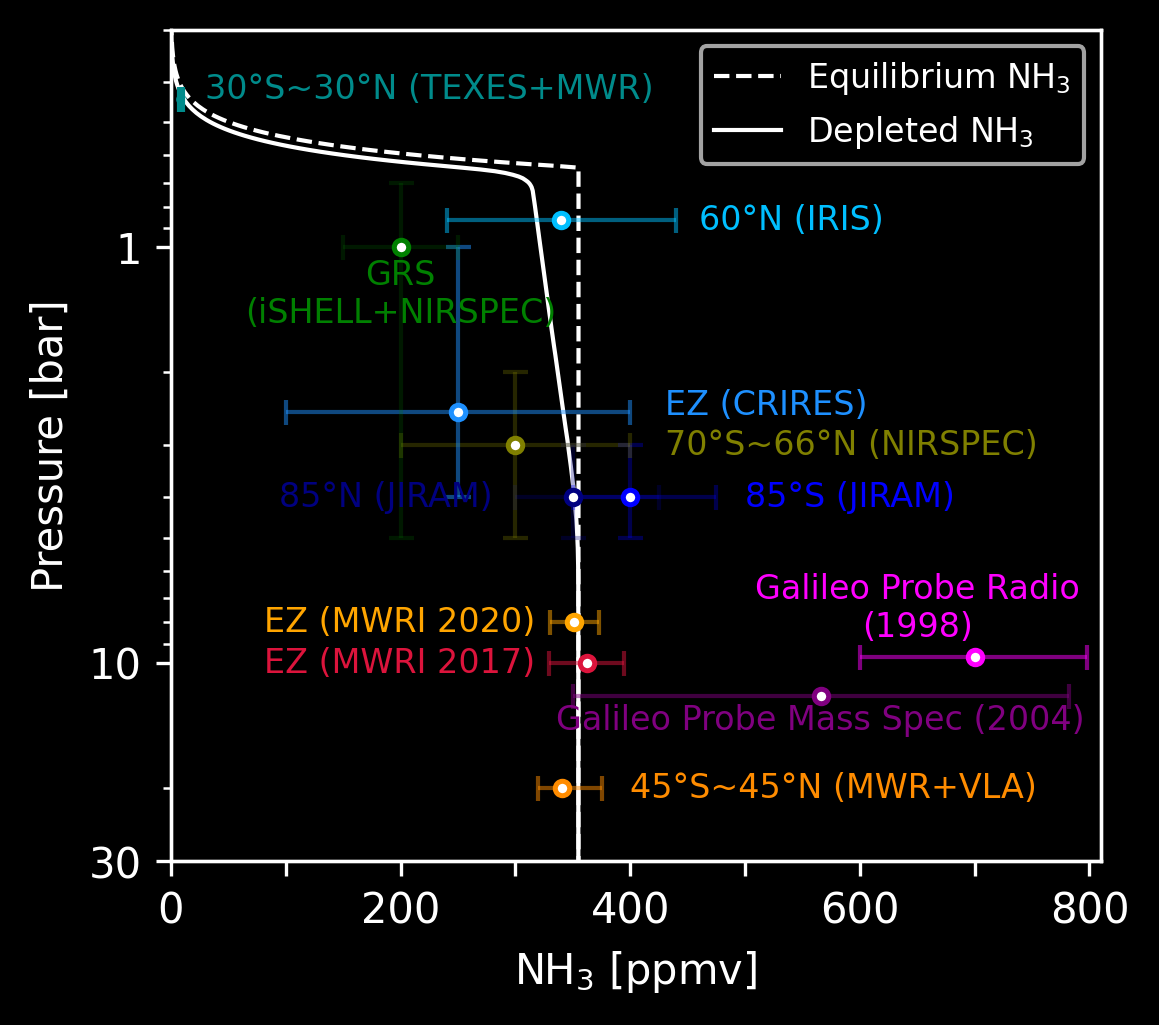

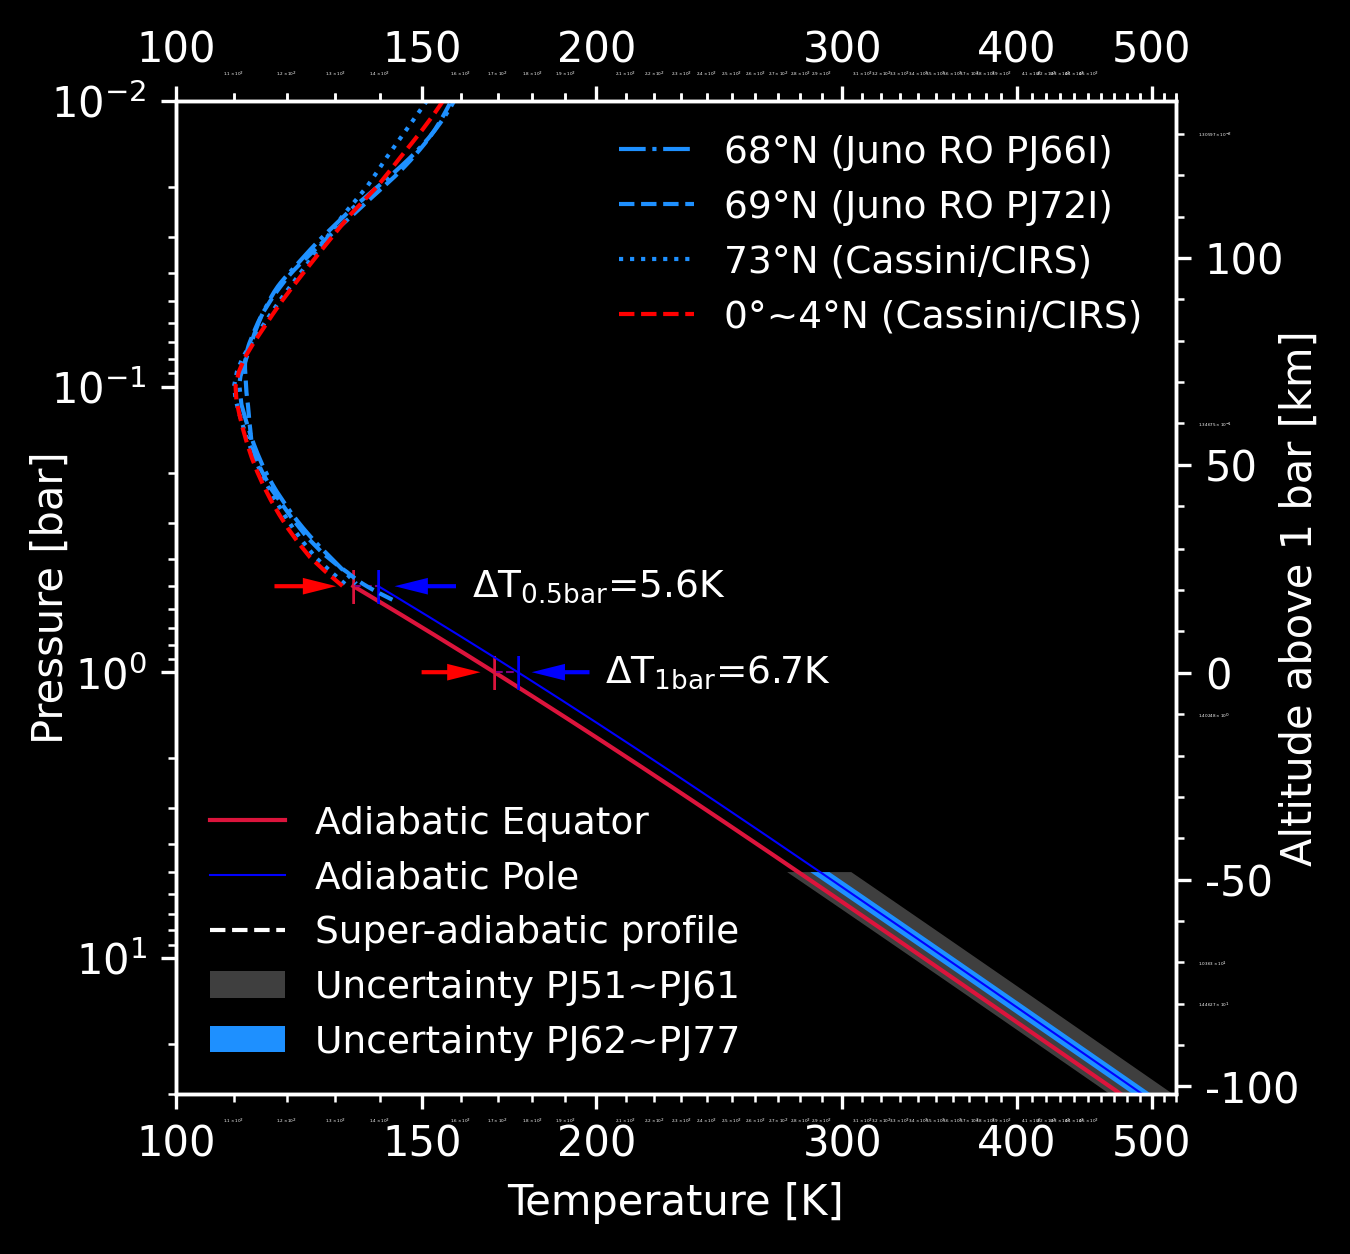

In [7]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')

import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator

# Open Juno MWR NetCDF file
juno = h5py.File("/home/jihenghu/JHCanoe/build_euler_apative_bg_pseudo/bin/juno_mwr-main.nc", "r")

# Read pressure data and convert units
pressure_bars = juno["press"][0,:,0,0] * 0.00001

# Open the HDF5 file in read mode
filename = "../moist_adiab/reconstruct_atmos_profiles_moist_last5000.h5"
with h5py.File(filename, 'r') as profIN:
    # Extract datasets
    SH_NH3 = profIN['NH3_ppmv'][:, :, :]
    SH_H2O = profIN['H2O_ppmv'][:, :, :]/1000.


filename="../dry_adiab/reconstruct_atmos_profiles_last5000.h5"
with h5py.File(filename, 'r') as profIN:
    # Extract datasets
    SH_NH3_dry = profIN['NH3_ppmv'][:, :, :]
    SH_H2O_dry = profIN['H2O_ppmv'][:, :, :]/1000.

NH3 = np.median(SH_NH3, axis=(0,1))
devNH3 = np.std(SH_NH3, axis=(0,1))


NH3_dry = np.median(SH_NH3_dry, axis=(0,1))
devNH3_dry = np.std(SH_NH3_dry, axis=(0,1))


# from matplotlib.gridspec import GridSpec
# fig = plt.figure(figsize=(7, 12), dpi=300)
# gs = GridSpec(1, 2, width_ratios=[3, 2], wspace=0.2)
# ax1 = fig.add_subplot(gs[0, 0])
# ax2 = fig.add_subplot(gs[0, 1])
fig, ax1 = plt.subplots(1, 1, figsize=(4, 3.6), dpi=300)
# fig.subplots_adjust(hspace=0.21)


ax1.plot(NH3, pressure_bars,'w--', linewidth=1,label=r"NP (equilibrium NH$_3$)")
ax1.fill_betweenx(pressure_bars, NH3 - devNH3, NH3 + devNH3, color='k', alpha=0.2, linewidth=0)

ax1.plot(NH3_dry, pressure_bars, 'w-',linewidth=1, label=r"NP (depleted NH$_3$)")
ax1.fill_betweenx(pressure_bars, NH3_dry - devNH3_dry, NH3_dry + devNH3_dry, color='k', alpha=0.1, linewidth=0)

# ax1.set_xlabel(r'Mixing ratio [ppm]')
ax1.set_ylabel('Pressure [bar]')  # Units in bar
# ax1.set_title('Temperature Profiles of NH3 and H2O')
# ax1.legend()
# ax1.grid()

# Set y-axis to logarithmic scale
ax1.set_yscale('log')
# ax1.set_xscale('log')
ax1.set_xlabel(r'NH$_3$ [ppmv]')

# Set y-limits
ax1.set_ylim(0.3, 30)  # Inverted to match log scale
ax1.set_xlim(0,810)  # Inverted to match log scale
ax1.set_xticks([0,100,200,300,400,500,600,700,800])

ax1.set_yticks([1, 10, 30])  # Inverted to match log scale
ax1.set_yticklabels([1, 10, 30])  # Inverted to match log scale
# ax1.set_xticklabels(['0','100','200','300','400','500','','700'])
ax1.set_xticklabels(['0','','200','','400','','600','','800'])
ax1.invert_yaxis()  # Invert y-axis for atmospheric profiles






alpha= 0.5
fontsize=8
# li 2020
ax1.errorbar( 351, 8,xerr=[[21], [22]], fmt='', color='orange', ecolor='orange', capsize=3, linewidth=1,alpha=alpha, label= "EZ (Li, 2020)")
ax1.text( 317, 8, "EZ (MWRI 2020)", ha="right", va="center" , color='orange', fontsize=fontsize)

# li 2017
ax1.errorbar( 362, 10,xerr=[[33], [33]], fmt='', color='crimson', ecolor='crimson', capsize=3, linewidth=1, alpha=alpha, label="EZ (Li, 2017)")
ax1.text( 317, 10, "EZ (MWRI 2017)", ha="right" , va="center", color='crimson', fontsize=fontsize)

# de pater 2016 
# ax1.plot( 570, 8, marker='o',  linestyle="", color='orange', label="EZ (de Pater, 2016)")
# ax1.text( 570, 6.5, "EZ (de Pater, 2016)", ha="center", va="center" , color='orange')

# grs galileo probe
ax1.errorbar( 566, 12,xerr=[[216], [216]], fmt='', color='purple', ecolor='purple', capsize=3, linewidth=1,alpha=alpha, label="Galileo Probe(Wong, 2004)")
ax1.text(566, 12.5, "Galileo Probe Mass Spec (2004)", ha="center",   va="top", color='purple', fontsize=fontsize)

# grs galileo probe
ax1.errorbar( 700, 9.7,xerr=[[100], [98]], fmt='', color='magenta', ecolor='magenta', capsize=3, linewidth=1,alpha=alpha, label="Galileo Probe(Folkner, 1998)")
ax1.text(650, 9, "Galileo Probe Radio\n(1998)", ha="center" , va="bottom", color='magenta', fontsize=fontsize)

# Moeckel
ax1.errorbar( 340.5, 20,xerr=[[21.2], [34.8]], fmt='', color='darkorange', ecolor='darkorange', capsize=3, linewidth=1, alpha=alpha,label="45°S~45°N(Moeckel, 2023)")
ax1.text(400, 20, "45°S~45°N (MWR+VLA)", ha="left", va="center", color='darkorange', fontsize=fontsize)

# Grassi
ax1.errorbar( 350, 4,xerr=[[50], [75]],yerr=[[1], [1]], fmt='', color='navy', ecolor='navy', capsize=3, linewidth=1,alpha=0.3, label="85°N (Grassi, 2020)")
ax1.text(280, 4, "85°N (JIRAM)", va="center" , ha="right", color='navy', fontsize=fontsize)

ax1.errorbar( 400, 4,xerr=[[50], [75]],yerr=[[1], [1]], fmt='', color='b', ecolor='b', capsize=3, linewidth=1, alpha=0.3, label="85°S (Grassi, 2020)")
ax1.text(500, 4, "85°S (JIRAM)", ha="left" , va="center", color='b', fontsize=fontsize)

# Bjoraker
ax1.errorbar( 300,3,xerr=[[100], [100]],yerr=[[1], [2]], fmt='', color='olive', ecolor='olive', capsize=3, linewidth=1,alpha=0.3, label= "70°S~66°N(Bjoraker, 2022)")
ax1.text(430, 3, "70°S~66°N (NIRSPEC)", ha="left" , va="center", color='olive', fontsize=fontsize)


# Giles
ax1.errorbar( 250, 2.5,xerr=[[150], [150]],yerr=[[1.5], [1.5]], fmt='', color='dodgerblue', ecolor='dodgerblue', capsize=3, linewidth=1,alpha=alpha, label="EZ (Giles, 2017)")
ax1.text(430, 2.4, "EZ (CRIRES)", ha="left" , va="center", color='dodgerblue', fontsize=fontsize)


ax1.errorbar( 8.8, 0.44,xerr=[[2], [2]], fmt='', color='darkcyan', ecolor='darkcyan', capsize=3, linewidth=1,alpha=1, label="30°S~30°N (Fletcher, 2020)")
ax1.text(30, 0.44, "30°S~30°N (TEXES+MWR)",  ha="left", color='darkcyan', fontsize=fontsize)

ax1.errorbar( 340, 0.86,xerr=[[100], [100]], fmt='', color='deepskyblue', ecolor='deepskyblue', capsize=3, linewidth=1,alpha=alpha, label="60°N (Fletcher, 2017)")
ax1.text(460, 0.86, "60°N (IRIS)", ha="left", va="center",color='deepskyblue', fontsize=fontsize)

# grs galileo probe
ax1.errorbar( 200, 1,xerr=[[50], [50]],yerr=[[0.3], [4]], fmt='', color='g', ecolor='g', capsize=3, linewidth=1,alpha=0.2, label="GRS (Bjoraker, 2018)")
ax1.text(200, 1.3, "GRS\n(iSHELL+NIRSPEC)", ha="center" , va="center", color='g', fontsize=fontsize)



##############333333333333
msize=12
lw=1.2
clr='white'
ax1.scatter( 351, 8,edgecolor='orange', label= "EZ (Li, 2020)",     s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 362, 10, edgecolor='crimson',label="EZ (Li, 2017)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 566, 12, edgecolor='purple', label="Galileo Probe(Wong, 2004)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 700, 9.7, edgecolor='magenta',  label="Galileo Probe(Folkner, 1998)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 340.5, 20, edgecolor='darkorange',label="45°S~45°N(Moeckel, 2023)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 350, 4, edgecolor='navy',  label="85°N (Grassi, 2020)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 400, 4, edgecolor='b',  label="85°S (Grassi, 2020)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 300,3, edgecolor='olive',  label= "70°S~66°N(Bjoraker, 2022)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 250, 2.5, edgecolor='dodgerblue',   label="EZ (Giles, 2017)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 8.8, 0.44,color='darkcyan', label="30°S~30°N (Fletcher, 2020)",    s=10, marker=".")
ax1.scatter( 340, 0.86, edgecolor='deepskyblue', label="60°N (Fletcher, 2017)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
ax1.scatter( 200, 1, edgecolor='g', label="GRS (Bjoraker, 2018)",    s=msize, marker="o",color=clr, linewidths=lw, zorder=10)

# ax1.text(-0.1, 1.07, "a", fontsize=16, fontweight='bold', va='top', ha='left',transform=ax1.transAxes)
# ax2.text(-0.18, 1.07, "b", fontsize=16, fontweight='bold', va='top', ha='left',transform=ax2.transAxes)
# ax2.text(-0.1, 1.07, "b", fontsize=16, fontweight='bold', va='top', ha='left',transform=ax2.transAxes)


axlegend=ax1.twiny()
axlegend.set_xticks([])
axlegend.plot([], [], 'w--', label=r"Equilibrium NH$_3$", linewidth=1)
axlegend.plot([], [], 'w-', label=r"Depleted NH$_3$", linewidth=1)

axlegend.legend(loc="upper right", fontsize=8)
# ax1.legend(loc="upper right", fontsize=8)


# read 'x1' from build/bin/juno_mwr-main.nc
with h5py.File("/data/jihenghu/juno-mwr-deconv-research/13.cpc.grid.retrv/build/bin/juno_mwr-main.nc", "r") as f:
    x1 = f["x1"][:]*1E-3 # km
xticks=[-100,-90,-80,-70,-60,-50,-40,-30,-20,-10,0,10,20,30]
pinx = np.interp(xticks, x1, pressure_bars)
print(pinx)

# axht = ax1.twinx()

# axht.set_ylim( 30,0.3)
# axht.set_yscale('log')

# axht.plot(x1, pressure_bars, color='k', linewidth=0)

# axht.set_yticks(pinx[1::3])      # Align ticks to pressure levels
# axht.set_yticklabels(xticks[1::3])   # Show height at each pressure
# axht.set_ylabel('Altitude above 1 bar [km]')

# from matplotlib.ticker import FixedLocator
# axht.yaxis.set_minor_locator(FixedLocator(pinx))
# axht.tick_params(axis='both', which='major',top =True, labelsize=10)
# axht.tick_params(axis='both', which='minor',top =True, labelcolor='white', labelsize=0)
# ==========
# for ax in [ax1, ]:
#     ax.grid(axis='both', which='major', linestyle='--', linewidth=0.5, alpha=0.5)
#     ax.grid(axis='y', which='both', linestyle='--', linewidth=0.5, alpha=0.5)

fig.savefig("fig4_reversed.pdf", dpi=300, bbox_inches='tight')

fig, ax2 = plt.subplots(1, 1, figsize=(4.3, 4.3), dpi=300)

# ax2.text(-0.1, 1.07, "b", fontsize=16, fontweight='bold', va='top', ha='left',transform=ax2.transAxes)

path="/home/jihenghu/JHCanoe/build_euler_apative_bg/bin"

# Open Juno MWR NetCDF file
juno = h5py.File(f"{path}/juno_mwr_dry_uniform_EZ-main.nc", "r")
pressure_bars = juno["press"][0,:,0,0] * 0.00001


# Open profile HDF5 file
profile = h5py.File(f"{path}/juno_mwr_dry_uniform_EZ-main.nc", "r")
Tropical = profile["temp"][0,:, 0, 0]

path="../dry_adiab/"

# profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP-main.nc", "r")
profile2 = h5py.File(f"{path}/juno_mwr_dryadiab_depletedNH3-main.nc", "r")
Tnp = profile2["temp"][0,:, 0, 0]

profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP-10-main.nc", "r")
Tnp_10 = profile2["temp"][0,:, 0, 0]
profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP+10-main.nc", "r")
Tnp10 = profile2["temp"][0,:, 0, 0]

profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP-3-main.nc", "r")
Tnp_3 = profile2["temp"][0,:, 0, 0]
profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP+3-main.nc", "r")
Tnp3 = profile2["temp"][0,:, 0, 0]

mask = pressure_bars >= 0.498

# Plot the curves with masked data
ax2.plot(Tropical[mask], pressure_bars[mask], label='Adiabatic Equator', color='crimson', alpha=1, linewidth=1)

mask = pressure_bars >= 4.98
ax2.plot(Tnp[mask], pressure_bars[mask], color='blue', alpha=1, linewidth=0.5,zorder=9)

# Masked fill_betweenx for the shaded regions
ax2.fill_betweenx(pressure_bars[mask], Tnp_10[mask], Tnp10[mask], color='lightgray', alpha=0.3, linewidth=0, zorder=0)
ax2.fill_betweenx(pressure_bars[mask], Tnp_3[mask], Tnp3[mask], color='dodgerblue', alpha=1, linewidth=0,zorder=8)

mask = (pressure_bars >= 0.498) & (pressure_bars <= 4.98)
ax2.plot(Tnp[mask], pressure_bars[mask], 'b-', alpha=1, linewidth=0.5, label='Adiabatic Pole',zorder=9)

ax2.plot([], [], 'w--', label='Super-adiabatic profile', linewidth=1)

# Label the primary axes
ax2.set_xlabel('Temperature [K]')
ax2.set_ylabel('Pressure [bar]',labelpad=-5)  # Units in bar
# ax1.set_title('Temperature Profiles of NH3 and H2O')
# ax1.yaxis.set_label_coords(-0.1, 1.)  # Adjust the x and y values to move label position



import matplotlib.patches as patches
rect1 = patches.Rectangle((-999, 0.9), 19, 0.15, linewidth=0, facecolor='lightgray', alpha=0.3, label="Uncertainty PJ51~PJ61")
rect2 = patches.Rectangle((-999, 0.9), 19, 0.15, linewidth=0, facecolor='dodgerblue', alpha=1, label="Uncertainty PJ62~PJ77")
ax2.add_patch(rect1)
ax2.add_patch(rect2)
# ax2.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.3, 0.91))

    
idx = np.argmin(np.abs(pressure_bars - 0.5))
temp_difference = Tnp[idx] - Tropical[idx]
ax2.text(163, 0.5,rf"$\Delta$T$_\text{{0.5bar}}$={temp_difference:0.1f}K",color='w', ha="left", va="center" , fontsize=9)

ax2.annotate('', xy=(Tnp[idx]+3, 0.5), xytext=(Tnp[idx]+20, 0.5),
    arrowprops=dict(facecolor='blue',  shrink=0.05, width=1, headwidth=4, headlength=8, edgecolor='none'),
    ha='left', va='bottom', color='blue')

ax2.annotate('', xy=(Tropical[idx]-3, 0.5), xytext=(Tropical[idx]-17, 0.5),
    arrowprops=dict(facecolor='red',  shrink=0.05, width=1, headwidth=4, headlength=8, edgecolor='none'),
    ha='left', va='bottom', color='red')

idx = np.argmin(np.abs(pressure_bars - 1))
temp_difference = Tnp[idx] - Tropical[idx]
ax2.text(203, 1,rf"$\Delta$T$_\text{{1bar}}$={temp_difference:0.1f}K",color='w', ha="left", va="center" , fontsize=9)

ax2.annotate('', xy=(Tnp[idx]+3, 1), xytext=(Tnp[idx]+23, 1),
    arrowprops=dict(facecolor='blue',  shrink=0.05, width=1, headwidth=4, headlength=8, edgecolor='none'),
    ha='left', va='bottom', color='blue')

ax2.annotate('', xy=(Tropical[idx]-3, 1), xytext=(Tropical[idx]-20, 1),
    arrowprops=dict(facecolor='red',  shrink=0.05, width=1, headwidth=4, headlength=8, edgecolor='none'),
    ha='left', va='bottom', color='red')


idx = np.argmin(np.abs(pressure_bars - 0.5))
ax2.text(Tropical[idx], 0.5, "|", color='crimson', ha="center", va="center" , fontsize=8)
ax2.text(Tnp[idx], 0.5, "|", color='b', ha="center", va="center" , fontsize=8)
ax2.plot([Tropical[idx], Tnp[idx]],[0.5,0.5], color='purple', linestyle='--', linewidth=0.5)


idx = np.argmin(np.abs(pressure_bars - 1))
ax2.text(Tropical[idx], 1, "|", color='crimson', ha="center", va="center" , fontsize=8)
ax2.text(Tnp[idx], 1, "|", color='b', ha="center", va="center" , fontsize=8)
ax2.plot([Tropical[idx], Tnp[idx]],[1,1], color='purple', linestyle='--', linewidth=0.5)


ax2.legend(frameon=False,loc='lower left', fontsize=9)





ax3=ax2.twiny()


for ax in [ax2, ax3]:
    ax.set_yscale('log')
    ax.set_ylim(0.01, 30)  # Inverted to match log scale
    # ax2.set_yticks([0.01,0.1,1,10,30])
    ax.invert_yaxis()

    ax.set_xscale('log')
    ax.set_xlim(100,520)  # Inverted to match log scale
    xminor=np.arange(100,530,10)
    ax.xaxis.set_minor_locator(FixedLocator(xminor))
    ax.set_xticks([100,150,200,300,400,500])
    ax.set_xticklabels([100,150,200,300,400,500])
    ax.tick_params(axis='x', which='minor',top =True, labelcolor='white', labelsize=0)
    # ax.set_xlabel('Temperature [K]')


import pandas as pd
from matplotlib.gridspec import GridSpec

# Load the CSV file

data = pd.read_csv('PJ66I.csv', header=None)
press = data[0]  # First column
pj66 = data[1]   # Second column
ax3.plot(pj66, press, 'dodgerblue', linestyle='-.', alpha=1, linewidth=1, label="68°N (Juno RO PJ66I)", )

# data = pd.read_csv('PJ54E_1.csv', header=None)
# press = data[0]  # First column
# pj54 = data[1]   # Second column
# ax3.plot(pj54, press, color="orange", linestyle='--',alpha=1, linewidth=1, label="15°N (Juno RO PJ54E_old)")
# data = pd.read_csv('PJ54E.csv', header=None)
# press = data[0]  # First column
# pj54 = data[1]   # Second column
# ax3.plot(pj54, press, color="orange", linestyle='-',alpha=1, linewidth=1, label="15°N (Juno RO PJ54E_new)")

data = pd.read_csv('PJ72I.csv', header=None)
press = data[0]  # First column
pj72 = data[1]   # Second column
ax3.plot(pj72, press, color="dodgerblue", linestyle='--',alpha=1, linewidth=1, label="69°N (Juno RO PJ72I)")



read_data = np.loadtxt('cassini_voyager_temp.txt', skiprows=1)
cassini_75 = read_data[:, 0]
# voyager_75 = read_data[:, 1]
cassini_ez = read_data[:, 2]
voyager_ez = read_data[:, 3]
pressure_unique = read_data[:, 4]

# Plot Cassini and Voyager data
ax3.plot(cassini_75, pressure_unique*1E-3, color='dodgerblue', linestyle=':', alpha=1, linewidth=1, label="73°N (Cassini/CIRS)")
ax3.plot(cassini_ez, pressure_unique*1E-3, color='red', linestyle='--', alpha=1, linewidth=1, label="0°~4°N (Cassini/CIRS)")
# ax3.plot(voyager_ez, pressure_unique*1E-3, color='magenta', linestyle='--', alpha=1, linewidth=1, label="0°~4°N (Voyager IRIS)")


ax3.legend(frameon=False,loc='upper right', fontsize=9)




################################3


xticks=[-100, -90, -80,-70,-60,-50,-40,-30,-20,-10,0,10,20,30,40,50,60,70,80,90,100,110,120,130]
pinx = np.interp(xticks, x1, pressure_bars)
print(pinx)

axht = ax2.twinx()
# axht.invert_yaxis()  # Invert y-axis to match pressure scale
axht.set_ylim( 30,0.01)
axht.set_yscale('log')

axht.plot(x1, pressure_bars, color='k', linewidth=0)

axht.set_yticks(pinx[::5])      # Align ticks to pressure levels
axht.set_yticklabels(xticks[::5])   # Show height at each pressure
axht.set_ylabel('Altitude above 1 bar [km]',labelpad=-5)

from matplotlib.ticker import FixedLocator
axht.yaxis.set_minor_locator(FixedLocator(pinx))
axht.tick_params(axis='both', which='major',top =True, labelsize=10)
axht.tick_params(axis='both', which='minor',top =True, labelcolor='white', labelsize=0)



# for ax in [ax1, ax2]:
#     ax.grid(axis='both', which='major', linestyle='--', linewidth=0.5, alpha=0.5)
#     ax.grid(axis='y', which='both', linestyle='--', linewidth=0.5, alpha=0.5)
     
# plt.show()
fig.savefig("fig5_reversed.pdf", dpi=300, bbox_inches='tight')

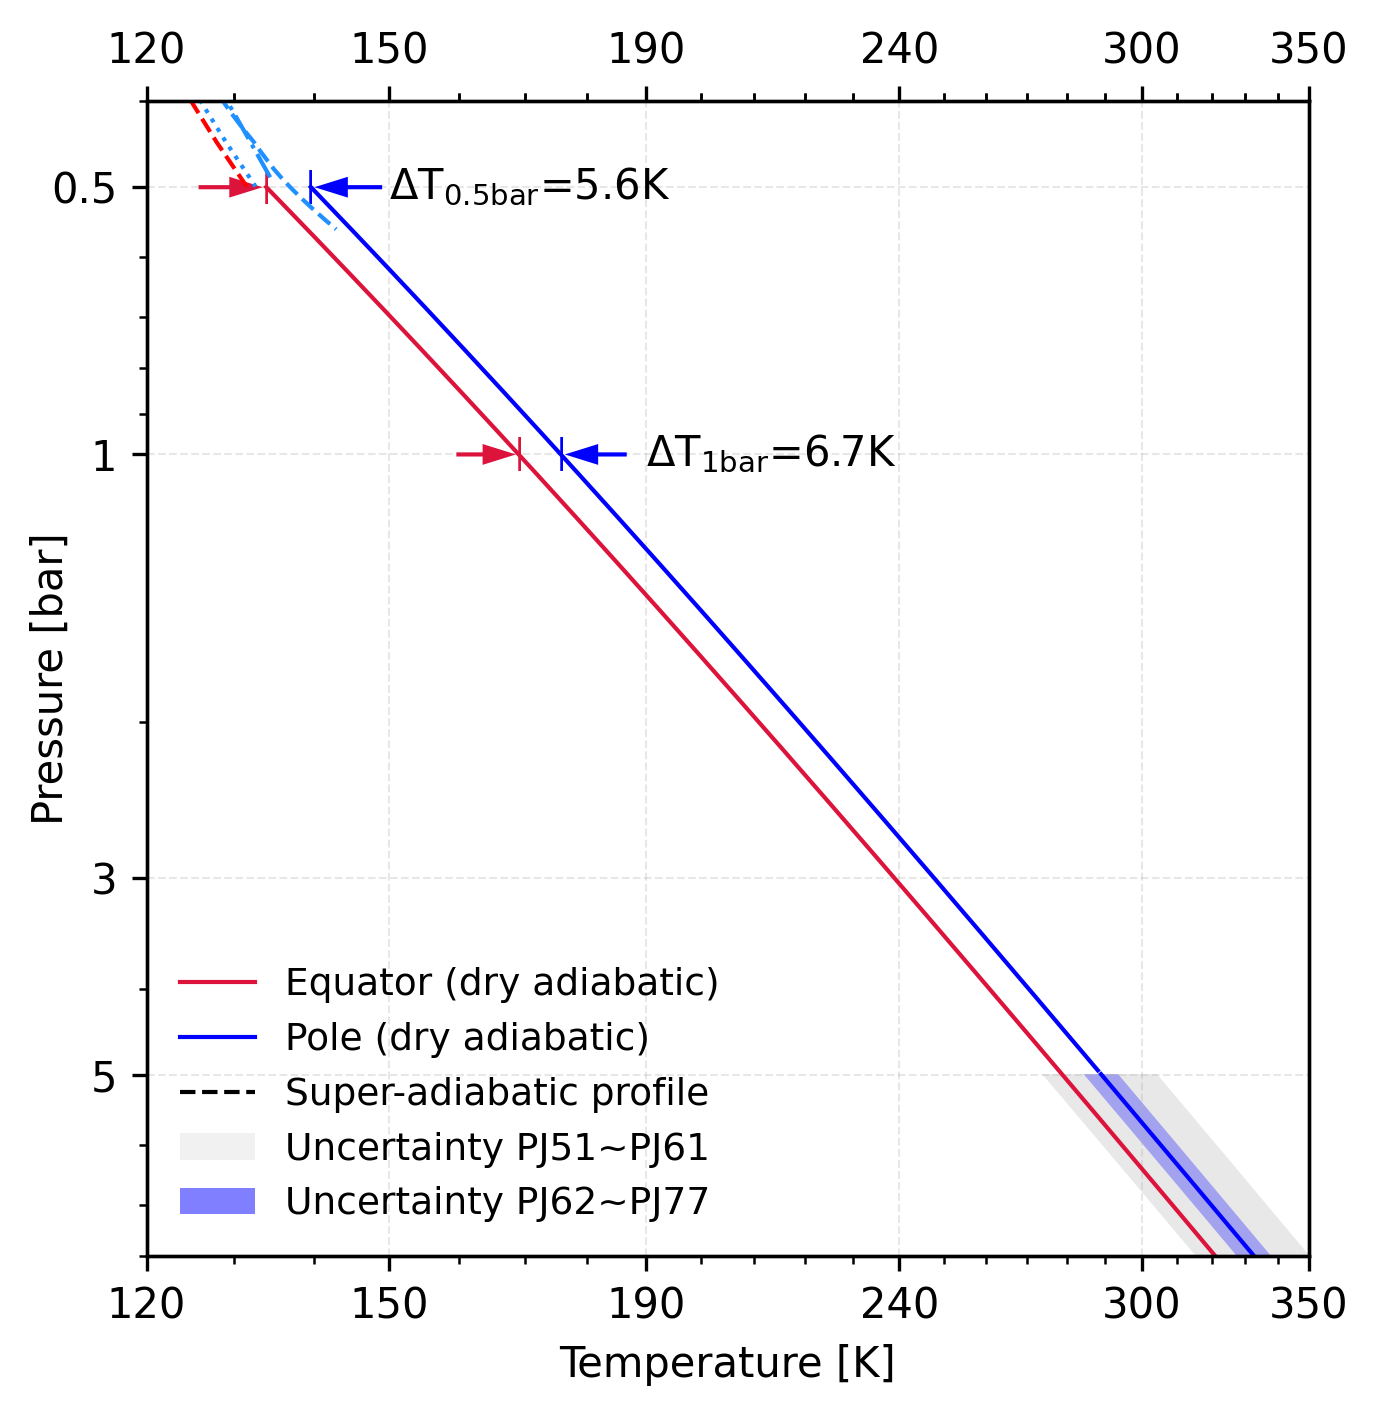

In [12]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator

fig, ax2 = plt.subplots(1, 1, figsize=(5, 5), dpi=300)

path="/home/jihenghu/JHCanoe/build_euler_apative_bg/bin"
juno = h5py.File(f"{path}/juno_mwr_dry_uniform_EZ-main.nc", "r")
pressure_bars = juno["press"][0,:,0,0] * 0.00001

profile = h5py.File(f"{path}/juno_mwr_dry_uniform_EZ-main.nc", "r")
Tropical = profile["temp"][0,:, 0, 0]

path="../dry_adiab/"
profile2 = h5py.File(f"{path}/juno_mwr_dryadiab_depletedNH3-main.nc", "r")
Tnp = profile2["temp"][0,:, 0, 0]

profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP-10-main.nc", "r")
Tnp_10 = profile2["temp"][0,:, 0, 0]
profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP+10-main.nc", "r")
Tnp10 = profile2["temp"][0,:, 0, 0]

profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP-3-main.nc", "r")
Tnp_3 = profile2["temp"][0,:, 0, 0]
profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP+3-main.nc", "r")
Tnp3 = profile2["temp"][0,:, 0, 0]

mask = pressure_bars >= 0.498

# Plot the curves with masked data
ax2.plot(Tropical[mask], pressure_bars[mask], label='Equator (dry adiabatic)', color='crimson', alpha=1, linewidth=1)

mask = pressure_bars >= 4.98
ax2.plot(Tnp[mask], pressure_bars[mask], color='blue', alpha=1, linewidth=1)

# Masked fill_betweenx for the shaded regions
ax2.fill_betweenx(pressure_bars[mask], Tnp_10[mask], Tnp10[mask], color='lightgray', alpha=0.5, linewidth=0, )
ax2.fill_betweenx(pressure_bars[mask], Tnp_3[mask], Tnp3[mask], color='b', alpha=0.3, linewidth=0)

mask = (pressure_bars >= 0.498) & (pressure_bars <= 4.98)
ax2.plot(Tnp[mask], pressure_bars[mask], 'b-', alpha=1, linewidth=1, label='Pole (dry adiabatic)')

ax2.plot([], [], 'k--', label='Super-adiabatic profile', linewidth=1)

# Label the primary axes
ax2.set_xlabel('Temperature [K]')
ax2.set_ylabel('Pressure [bar]',labelpad=-5)  # Units in bar



import matplotlib.patches as patches
rect1 = patches.Rectangle((-999, 0.9), 19, 0.15, linewidth=0, facecolor='lightgray', alpha=0.3, label="Uncertainty PJ51~PJ61")
rect2 = patches.Rectangle((-999, 0.9), 19, 0.15, linewidth=0, facecolor='b', alpha=0.5, label="Uncertainty PJ62~PJ77")
ax2.add_patch(rect1)
ax2.add_patch(rect2)
# ax2.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.3, 0.91))

    
idx = np.argmin(np.abs(pressure_bars - 0.5))
temp_difference = Tnp[idx] - Tropical[idx]
ax2.text(150, 0.5,rf"$\Delta$T$_\text{{0.5bar}}$={temp_difference:0.1f}K",color='k', ha="left", va="center" )


ax2.annotate('', xy=(Tnp[idx], 0.5), xytext=(Tnp[idx]+10, 0.5),
    arrowprops=dict(facecolor='blue',  shrink=0.05, width=1, headwidth=5, headlength=8, edgecolor='none'),
    ha='left', va='bottom', color='blue')

ax2.annotate('', xy=(Tropical[idx], 0.5), xytext=(Tropical[idx]-8.5, 0.5),
    arrowprops=dict(facecolor='crimson',  shrink=0.05, width=1, headwidth=5, headlength=8, edgecolor='none'),
    ha='left', va='bottom', color='crimson')





idx = np.argmin(np.abs(pressure_bars - 1))
temp_difference = Tnp[idx] - Tropical[idx]
ax2.text(190, 1,rf"$\Delta$T$_\text{{1bar}}$={temp_difference:0.1f}K",color='k', ha="left", va="center")

ax2.annotate('', xy=(Tnp[idx], 1), xytext=(Tnp[idx]+11.5, 1),
    arrowprops=dict(facecolor='blue',  shrink=0.05, width=1, headwidth=5, headlength=8, edgecolor='none'),
    ha='left', va='bottom', color='blue')

ax2.annotate('', xy=(Tropical[idx], 1), xytext=(Tropical[idx]-10, 1),
    arrowprops=dict(facecolor='crimson',  shrink=0.05, width=1, headwidth=5, headlength=8, edgecolor='none'),
    ha='left', va='bottom', color='crimson')


idx = np.argmin(np.abs(pressure_bars - 0.5))
ax2.text(Tropical[idx], 0.5, "|", color='crimson', ha="center", va="center" , fontsize=8)
ax2.text(Tnp[idx], 0.5, "|", color='b', ha="center", va="center" , fontsize=8)
# ax2.plot([Tropical[idx], Tnp[idx]],[0.5,0.5], color='purple', linestyle='--', linewidth=0.5)


idx = np.argmin(np.abs(pressure_bars - 1))
ax2.text(Tropical[idx], 1, "|", color='crimson', ha="center", va="center" , fontsize=8)
ax2.text(Tnp[idx], 1, "|", color='b', ha="center", va="center" , fontsize=8)
# ax2.plot([Tropical[idx], Tnp[idx]],[1,1], color='purple', linestyle='--', linewidth=0.5)


ax2.legend(frameon=False,loc='lower left', fontsize=9)

ax2.grid(axis='both', which='major', linestyle='--', linewidth=0.5, alpha=0.3)


ax3=ax2.twiny()

for ax in [ax2, ax3]:
    ax.set_yscale('log')
    ax.set_ylim(0.4, 8)  # Inverted to match log scale
    ax2.set_yticks([0.5,1,3,5])
    ax2.set_yticklabels([0.5,1,3,5])
    ax.invert_yaxis()

    ax.set_xscale('log')
    ax.set_xlim(120,350)  # Inverted to match log scale
    xminor=np.arange(120,350,10)
    ax.xaxis.set_minor_locator(FixedLocator(xminor))
    ax.set_xticks([120,150,190,240,300,350])
    ax.set_xticklabels([120,150,190,240,300,350])
    ax.tick_params(axis='x', which='minor',top =True, labelcolor='white', labelsize=0)
    # ax.set_xlabel('Temperature [K]')


import pandas as pd
from matplotlib.gridspec import GridSpec

# Load the CSV file

data = pd.read_csv('PJ66I.csv', header=None)
press = data[0]  # First column
pj66 = data[1]   # Second column
ax3.plot(pj66, press, 'dodgerblue', linestyle='-.', alpha=1, linewidth=1, label="68°N (Juno RO PJ66I)", )

data = pd.read_csv('PJ72I.csv', header=None)
press = data[0]  # First column
pj72 = data[1]   # Second column
ax3.plot(pj72, press, color="dodgerblue", linestyle='--',alpha=1, linewidth=1, label="69°N (Juno RO PJ72I)")


read_data = np.loadtxt('cassini_voyager_temp.txt', skiprows=1)
cassini_75 = read_data[:, 0]
# voyager_75 = read_data[:, 1]
cassini_ez = read_data[:, 2]
voyager_ez = read_data[:, 3]
pressure_unique = read_data[:, 4]

# Plot Cassini and Voyager data
ax3.plot(cassini_75, pressure_unique*1E-3, color='dodgerblue', linestyle=':', alpha=1, linewidth=1, label="73°N (Cassini/CIRS)")
ax3.plot(cassini_ez, pressure_unique*1E-3, color='red', linestyle='--', alpha=1, linewidth=1, label="0°~4°N (Cassini/CIRS)")
# ax3.plot(voyager_ez, pressure_unique*1E-3, color='magenta', linestyle='--', alpha=1, linewidth=1, label="0°~4°N (Voyager IRIS)")


# ax3.legend(frameon=False,  fontsize=8, bbox_to_anchor=(0.2, 0.8))



plt.show()

[2.81694290e+01 2.01842972e+01 1.44626949e+01 1.03629814e+01
 7.42540455e+00 5.32053655e+00 3.81233199e+00 2.73165513e+00
 1.95731612e+00 1.40247781e+00 1.00491877e+00 7.20055312e-01
 5.15941722e-01 3.69688040e-01 2.62311630e-01 1.87954244e-01
 1.34674907e-01 9.64986040e-02 6.91441396e-02 4.95439976e-02
 3.54998852e-02 2.54368217e-02 1.82263086e-02 1.30597350e-02]


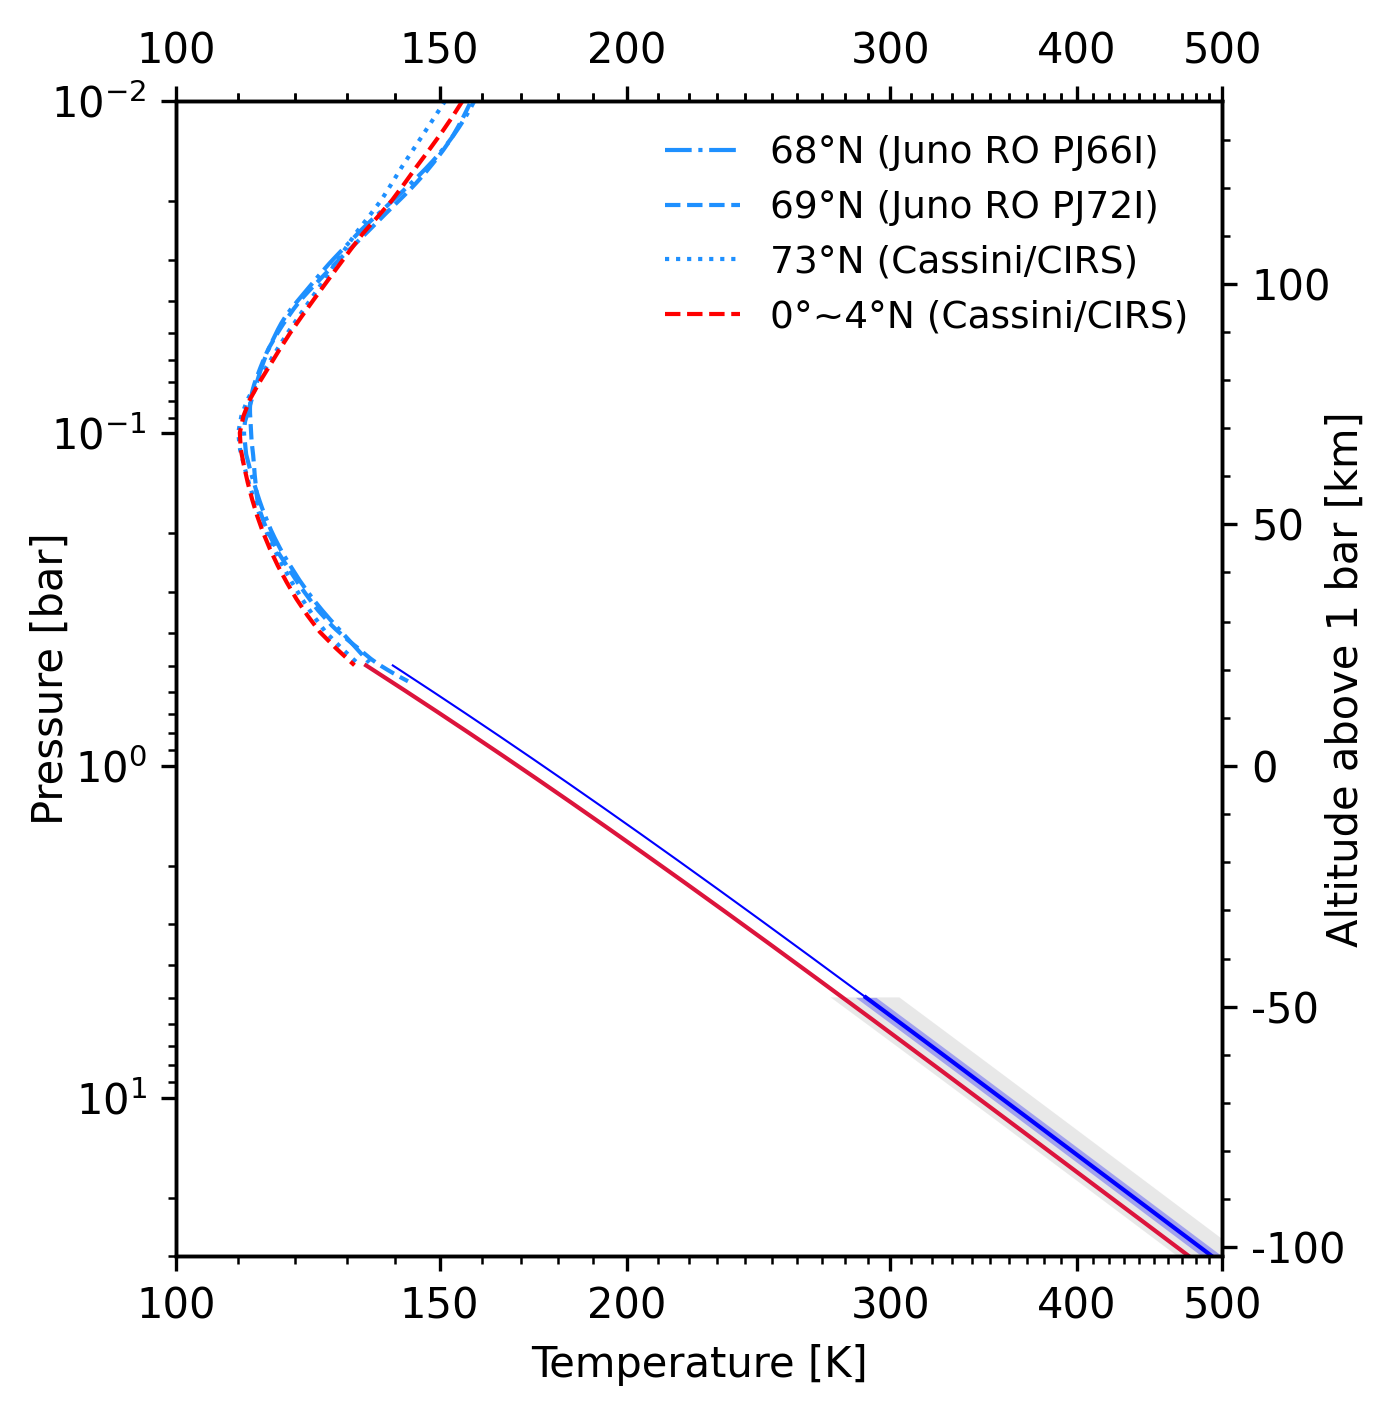

In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator


# read 'x1' from build/bin/juno_mwr-main.nc
with h5py.File("/data/jihenghu/juno-mwr-deconv-research/13.cpc.grid.retrv/build/bin/juno_mwr-main.nc", "r") as f:
    x1 = f["x1"][:]*1E-3 # km


fig, ax2 = plt.subplots(1, 1, figsize=(4.5, 5), dpi=300)

# ax2.text(-0.1, 1.07, "b", fontsize=16, fontweight='bold', va='top', ha='left',transform=ax2.transAxes)

path="/home/jihenghu/JHCanoe/build_euler_apative_bg/bin"

# Open Juno MWR NetCDF file
juno = h5py.File(f"{path}/juno_mwr_dry_uniform_EZ-main.nc", "r")
pressure_bars = juno["press"][0,:,0,0] * 0.00001


# Open profile HDF5 file
profile = h5py.File(f"{path}/juno_mwr_dry_uniform_EZ-main.nc", "r")
Tropical = profile["temp"][0,:, 0, 0]

path="../dry_adiab/"

# profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP-main.nc", "r")
profile2 = h5py.File(f"{path}/juno_mwr_dryadiab_depletedNH3-main.nc", "r")
Tnp = profile2["temp"][0,:, 0, 0]

profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP-10-main.nc", "r")
Tnp_10 = profile2["temp"][0,:, 0, 0]
profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP+10-main.nc", "r")
Tnp10 = profile2["temp"][0,:, 0, 0]

profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP-3-main.nc", "r")
Tnp_3 = profile2["temp"][0,:, 0, 0]
profile2 = h5py.File(f"{path}/juno_mwr_dry_uniform_NP+3-main.nc", "r")
Tnp3 = profile2["temp"][0,:, 0, 0]

mask = pressure_bars >= 0.498

# Plot the curves with masked data
ax2.plot(Tropical[mask], pressure_bars[mask], label='Adiabatic Equator', color='crimson', alpha=1, linewidth=1)

mask = pressure_bars >= 4.98
ax2.plot(Tnp[mask], pressure_bars[mask], color='blue', alpha=1, linewidth=1)

# Masked fill_betweenx for the shaded regions
ax2.fill_betweenx(pressure_bars[mask], Tnp_10[mask], Tnp10[mask], color='lightgray', alpha=0.5, linewidth=0)
ax2.fill_betweenx(pressure_bars[mask], Tnp_3[mask], Tnp3[mask], color='b', alpha=0.3, linewidth=0)

mask = (pressure_bars >= 0.498) & (pressure_bars <= 4.98)
ax2.plot(Tnp[mask], pressure_bars[mask], 'b-', alpha=1, linewidth=0.5, label='Adiabatic Pole')

ax2.plot([], [], 'k--', label='Super-adiabatic profile', linewidth=1)

# Label the primary axes
ax2.set_xlabel('Temperature [K]')
ax2.set_ylabel('Pressure [bar]',labelpad=-5)  # Units in bar
# ax1.set_title('Temperature Profiles of NH3 and H2O')
# ax1.yaxis.set_label_coords(-0.1, 1.)  # Adjust the x and y values to move label position



import matplotlib.patches as patches
rect1 = patches.Rectangle((-999, 0.9), 19, 0.15, linewidth=0, facecolor='lightgray', alpha=1, label="Uncertainty PJ51~PJ61")
rect2 = patches.Rectangle((-999, 0.9), 19, 0.15, linewidth=0, facecolor='b', alpha=0.3, label="Uncertainty PJ62~PJ77")
ax2.add_patch(rect1)
ax2.add_patch(rect2)
# ax2.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.3, 0.91))

    
# idx = np.argmin(np.abs(pressure_bars - 0.5))
# temp_difference = Tnp[idx] - Tropical[idx]
# ax2.text(163, 0.5,rf"$\Delta$T$_\text{{0.5bar}}$={temp_difference:0.1f}K",color='k', ha="left", va="center" , fontsize=9)

# ax2.annotate('', xy=(Tnp[idx]+3, 0.5), xytext=(Tnp[idx]+20, 0.5),
#     arrowprops=dict(facecolor='blue',  shrink=0.05, width=1, headwidth=4, headlength=8, edgecolor='none'),
#     ha='left', va='bottom', color='blue')

# ax2.annotate('', xy=(Tropical[idx]-3, 0.5), xytext=(Tropical[idx]-17, 0.5),
#     arrowprops=dict(facecolor='red',  shrink=0.05, width=1, headwidth=4, headlength=8, edgecolor='none'),
#     ha='left', va='bottom', color='red')

# idx = np.argmin(np.abs(pressure_bars - 1))
# temp_difference = Tnp[idx] - Tropical[idx]
# ax2.text(203, 1,rf"$\Delta$T$_\text{{1bar}}$={temp_difference:0.1f}K",color='k', ha="left", va="center" , fontsize=9)

# ax2.annotate('', xy=(Tnp[idx]+3, 1), xytext=(Tnp[idx]+23, 1),
#     arrowprops=dict(facecolor='blue',  shrink=0.05, width=1, headwidth=4, headlength=8, edgecolor='none'),
#     ha='left', va='bottom', color='blue')

# ax2.annotate('', xy=(Tropical[idx]-3, 1), xytext=(Tropical[idx]-20, 1),
#     arrowprops=dict(facecolor='red',  shrink=0.05, width=1, headwidth=4, headlength=8, edgecolor='none'),
#     ha='left', va='bottom', color='red')


# idx = np.argmin(np.abs(pressure_bars - 0.5))
# ax2.text(Tropical[idx], 0.5, "|", color='crimson', ha="center", va="center" , fontsize=8)
# ax2.text(Tnp[idx], 0.5, "|", color='b', ha="center", va="center" , fontsize=8)
# ax2.plot([Tropical[idx], Tnp[idx]],[0.5,0.5], color='purple', linestyle='--', linewidth=0.5)


# idx = np.argmin(np.abs(pressure_bars - 1))
# ax2.text(Tropical[idx], 1, "|", color='crimson', ha="center", va="center" , fontsize=8)
# ax2.text(Tnp[idx], 1, "|", color='b', ha="center", va="center" , fontsize=8)
# ax2.plot([Tropical[idx], Tnp[idx]],[1,1], color='purple', linestyle='--', linewidth=0.5)


# ax2.legend(frameon=False, loc='lower left', fontsize=9)





ax3=ax2.twiny()


for ax in [ax2, ax3]:
    ax.set_yscale('log')
    ax.set_ylim(0.01, 30)  # Inverted to match log scale
    # ax2.set_yticks([0.01,0.1,1,10,30])
    ax.invert_yaxis()

    ax.set_xscale('log')
    ax.set_xlim(100,500)  # Inverted to match log scale
    xminor=np.arange(100,500,10)
    ax.xaxis.set_minor_locator(FixedLocator(xminor))
    ax.set_xticks([100,150,200,300,400,500])
    ax.set_xticklabels([100,150,200,300,400,500])
    ax.tick_params(axis='x', which='minor',top =True, labelcolor='white', labelsize=0)
    # ax.set_xlabel('Temperature [K]')


import pandas as pd
from matplotlib.gridspec import GridSpec

# Load the CSV file

data = pd.read_csv('PJ66I.csv', header=None)
press = data[0]  # First column
pj66 = data[1]   # Second column
ax3.plot(pj66, press, 'dodgerblue', linestyle='-.', alpha=1, linewidth=1, label="68°N (Juno RO PJ66I)", )

# data = pd.read_csv('PJ54E_1.csv', header=None)
# press = data[0]  # First column
# pj54 = data[1]   # Second column
# ax3.plot(pj54, press, color="orange", linestyle='--',alpha=1, linewidth=1, label="15°N (Juno RO PJ54E_old)")
# data = pd.read_csv('PJ54E.csv', header=None)
# press = data[0]  # First column
# pj54 = data[1]   # Second column
# ax3.plot(pj54, press, color="orange", linestyle='-',alpha=1, linewidth=1, label="15°N (Juno RO PJ54E_new)")

data = pd.read_csv('PJ72I.csv', header=None)
press = data[0]  # First column
pj72 = data[1]   # Second column
ax3.plot(pj72, press, color="dodgerblue", linestyle='--',alpha=1, linewidth=1, label="69°N (Juno RO PJ72I)")



read_data = np.loadtxt('cassini_voyager_temp.txt', skiprows=1)
cassini_75 = read_data[:, 0]
# voyager_75 = read_data[:, 1]
cassini_ez = read_data[:, 2]
voyager_ez = read_data[:, 3]
pressure_unique = read_data[:, 4]

# Plot Cassini and Voyager data
ax3.plot(cassini_75, pressure_unique*1E-3, color='dodgerblue', linestyle=':', alpha=1, linewidth=1, label="73°N (Cassini/CIRS)")
ax3.plot(cassini_ez, pressure_unique*1E-3, color='red', linestyle='--', alpha=1, linewidth=1, label="0°~4°N (Cassini/CIRS)")
# ax3.plot(voyager_ez, pressure_unique*1E-3, color='magenta', linestyle='--', alpha=1, linewidth=1, label="0°~4°N (Voyager IRIS)")


ax3.legend(frameon=False, fontsize=9, loc='upper right')




################################3


xticks=[-100, -90, -80,-70,-60,-50,-40,-30,-20,-10,0,10,20,30,40,50,60,70,80,90,100,110,120,130]
pinx = np.interp(xticks, x1, pressure_bars)
print(pinx)

axht = ax2.twinx()
# axht.invert_yaxis()  # Invert y-axis to match pressure scale
axht.set_ylim( 30,0.01)
axht.set_yscale('log')

axht.plot(x1, pressure_bars, color='k', linewidth=0)

axht.set_yticks(pinx[::5])      # Align ticks to pressure levels
axht.set_yticklabels(xticks[::5])   # Show height at each pressure
axht.set_ylabel('Altitude above 1 bar [km]',labelpad=-5)

from matplotlib.ticker import FixedLocator
axht.yaxis.set_minor_locator(FixedLocator(pinx))
axht.tick_params(axis='both', which='major',top =True, labelsize=10)
axht.tick_params(axis='both', which='minor',top =True, labelcolor='white', labelsize=0)



# for ax in [ax1, ax2]:
#     ax.grid(axis='both', which='major', linestyle='--', linewidth=0.5, alpha=0.5)
#     ax.grid(axis='y', which='both', linestyle='--', linewidth=0.5, alpha=0.5)
     
plt.show()


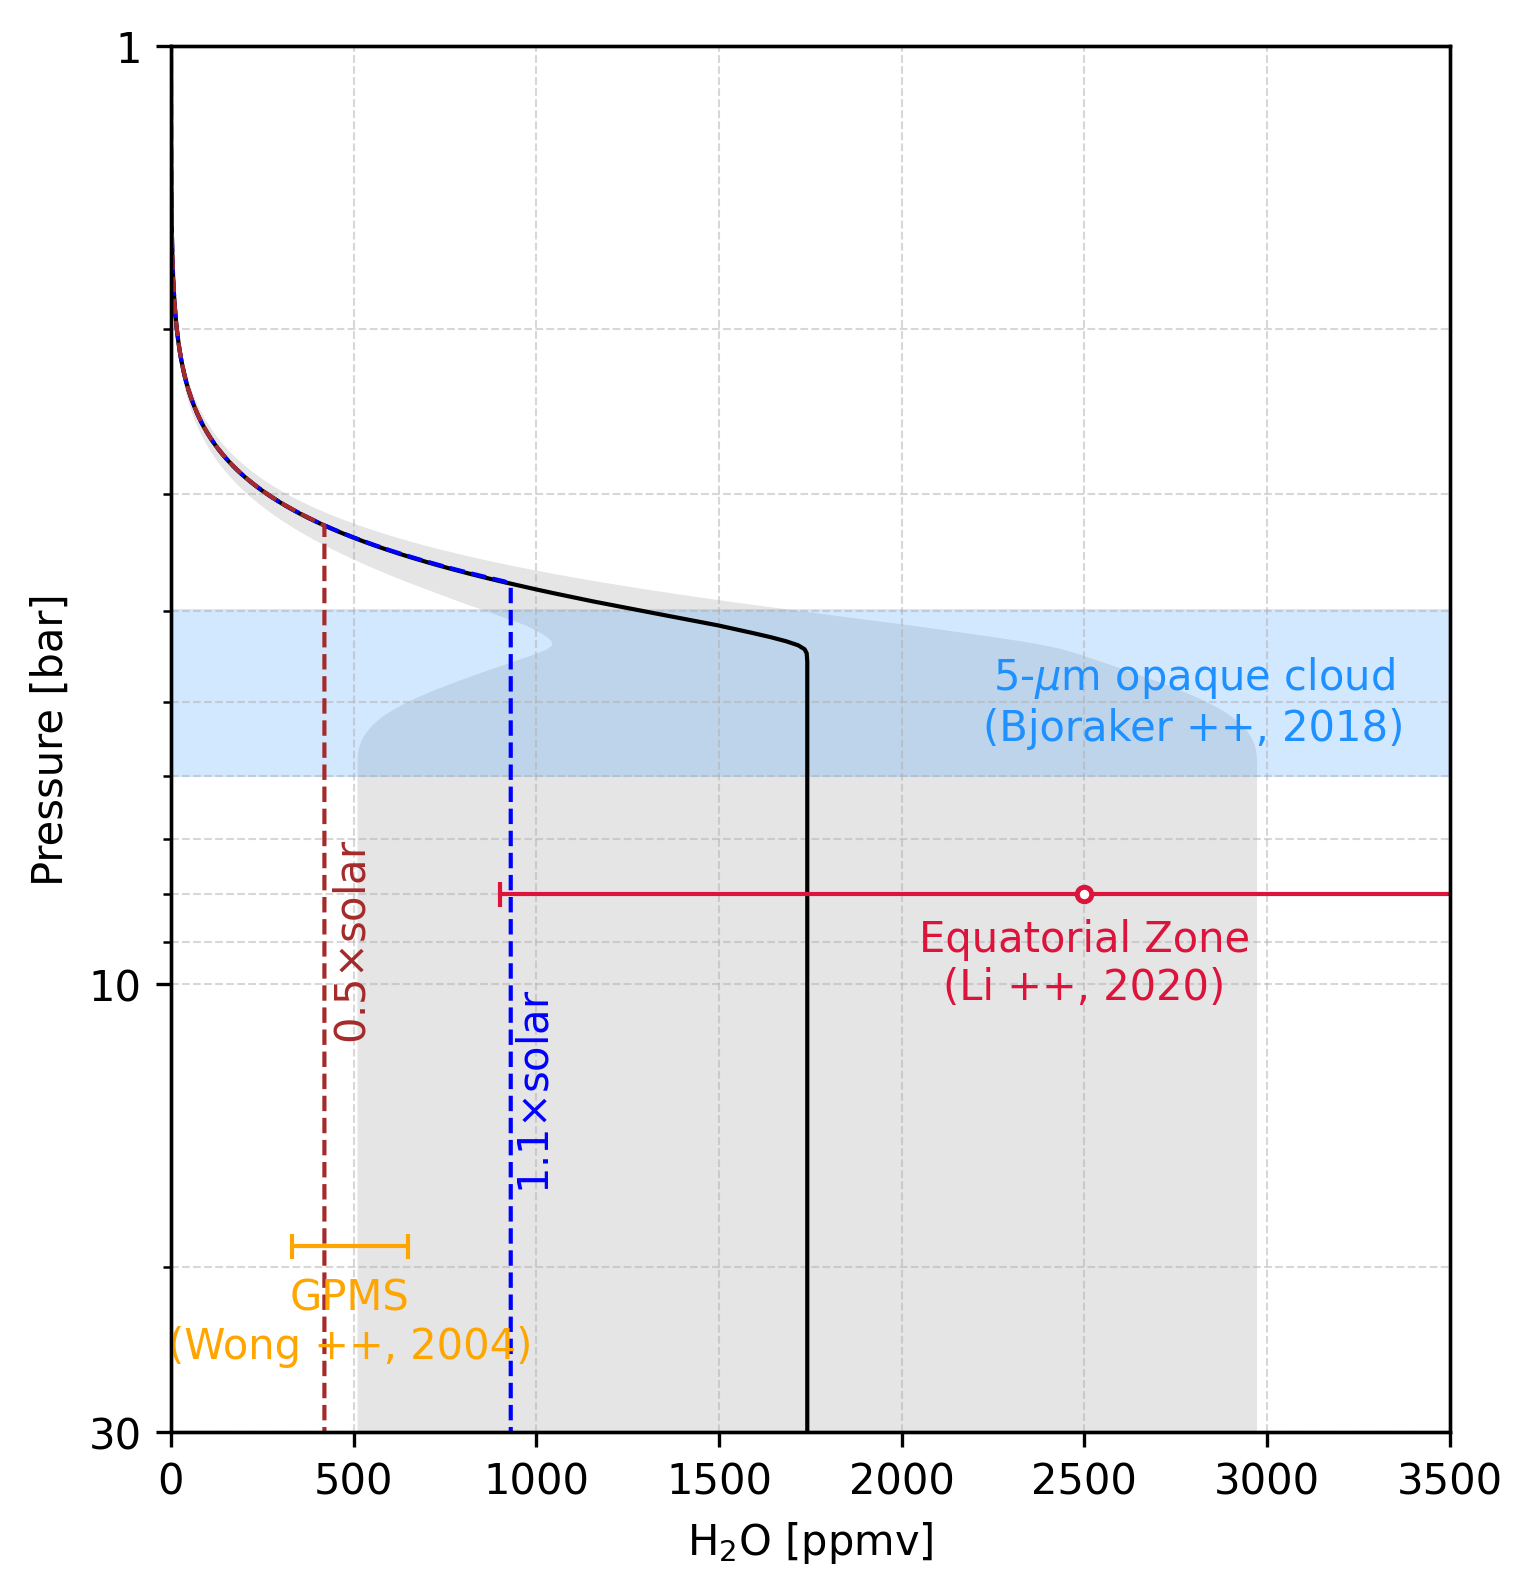

In [9]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator

# Open Juno MWR NetCDF file
juno = h5py.File("/home/jihenghu/JHCanoe/build_euler_apative_bg_pseudo/bin/juno_mwr-main.nc", "r")

# Read pressure data and convert units
pressure_bars = juno["press"][0,:,0,0] * 0.00001

# Open the HDF5 file in read mode
filename = "../moist_adiab/reconstruct_atmos_profiles_moist_last5000.h5"
with h5py.File(filename, 'r') as profIN:
    # Extract datasets
    # SH_NH3 = profIN['NH3_ppmv'][:, :, :]
    SH_H2O = profIN['H2O_ppmv'][:, :, :]



NH3 = np.median(SH_H2O, axis=(0,1))
devNH3 = np.std(SH_H2O, axis=(0,1))



fig, ax1 = plt.subplots(1, 1, figsize=(5.5, 6), dpi=300)



ax1.plot(NH3, pressure_bars,'k-', linewidth=1)
ax1.fill_betweenx(pressure_bars, NH3 - devNH3, NH3 + devNH3, color='k', alpha=0.1, linewidth=0)


# ax1.set_xlabel(r'Mixing ratio [ppm]')
ax1.set_ylabel('Pressure [bar]')  # Units in bar

ax1.grid()

# Set y-axis to logarithmic scale
ax1.set_yscale('log')
# ax1.set_xscale('log')
ax1.set_xlabel(r'H$_2$O [ppmv]')

# Set y-limits
ax1.set_ylim(1, 30)  # Inverted to match log scale
ax1.set_xlim(0,3500)  # Inverted to match log scale
# ax1.set_xticks([0,100,200,300,400,500,600,700,800])

ax1.set_yticks([1, 10, 30])  # Inverted to match log scale
ax1.set_yticklabels([1, 10, 30])  # Inverted to match log scale
# ax1.set_xticklabels(['0','100','200','300','400','500','','700'])
# ax1.set_xticklabels(['0','','200','','400','','600','','800'])
ax1.invert_yaxis()  # Invert y-axis for atmospheric profiles



# fill between 4-6 bar with dodgerblue
ax1.fill_betweenx(pressure_bars, 0, 4000, where=(pressure_bars >= 3.98) & (pressure_bars <= 6.01), color='dodgerblue', alpha=0.2, linewidth=0)
ax1.text(2800, 5, "5-$\mu$m opaque cloud\n(Bjoraker ++, 2018)", ha="center", va="center", color='dodgerblue', fontsize=10, alpha=1)


filename = "../moist_adiab/H2O_profiles_930ppmv.h5"
with h5py.File(filename, 'r') as profIN:
    SH_H2O1100 = profIN['h2o_ppm'][:]

ax1.plot(SH_H2O1100, pressure_bars,'b--', linewidth=1, label="1100 ppmv (moist adiabat)")
ax1.text(1000, 13, r"1.1$\times$solar", ha="center", va="center", color='blue', fontsize=10, alpha=1, rotation=90)


filename = "../moist_adiab/H2O_profiles_420ppmv.h5"
with h5py.File(filename, 'r') as profIN:
    SH_H2O490 = profIN['h2o_ppm'][:]

ax1.plot(SH_H2O490, pressure_bars,'--', color='brown', linewidth=1, label="490 ppmv (moist adiabat)")
ax1.text(500, 9, r"0.5$\times$solar", ha="center", va="center", color='brown', fontsize=10, alpha=1, rotation=90)




ax1.errorbar( 2500, 8,xerr=[[1600], [2200]], fmt='', color='crimson', ecolor='crimson', capsize=3, linewidth=1,alpha=alpha, label= "EZ (Li, 2020)")
ax1.text( 2500, 8.5, "Equatorial Zone\n(Li ++, 2020)", ha="center", va="top" , color='crimson', fontsize=10)

ax1.errorbar( 490, 19,xerr=[[160], [160]], fmt='', color='orange', ecolor='orange', capsize=3, linewidth=1,alpha=alpha)
ax1.text( 490, 20.5, "GPMS\n(Wong ++, 2004)", ha="center", va="top" , color='orange', fontsize=10)



msize=12
lw=1.2
clr='white'
ax1.scatter( 2500, 8,edgecolor='crimson', label= "EZ (Li, 2020)",     s=msize, marker="o",color=clr, linewidths=lw, zorder=10)
# ax1.scatter( 490, 20,edgecolor='orange', label= "GPMS (Wong et al., 2004)",     s=msize, marker="o",color=clr, linewidths=lw, zorder=10)




axlegend=ax1.twiny()
axlegend.set_xticks([])
# axlegend.plot([], [], 'k--', label=r"Equilibrium NH$_3$", linewidth=1)
# axlegend.plot([], [], 'k-', label=r"Depleted NH$_3$", linewidth=1)

# axlegend.legend(loc="upper right", fontsize=10)
# ax1.legend(loc="upper right", fontsize=8)


# # read 'x1' from build/bin/juno_mwr-main.nc
# with h5py.File("/data/jihenghu/juno-mwr-deconv-research/13.cpc.grid.retrv/build/bin/juno_mwr-main.nc", "r") as f:
#     x1 = f["x1"][:]*1E-3 # km
# xticks=[-100,-90,-80,-70,-60,-50,-40,-30,-20,-10,0]
# pinx = np.interp(xticks, x1, pressure_bars)
# print(pinx)

# axht = ax1.twinx()

# axht.set_ylim(30,1)
# axht.set_yscale('log')

# axht.plot(x1, pressure_bars, color='k', linewidth=0)

# axht.set_yticks(pinx[::2])      # Align ticks to pressure levels
# axht.set_yticklabels(xticks[::2])   # Show height at each pressure
# axht.set_ylabel('Altitude above 1 bar [km]')

# from matplotlib.ticker import FixedLocator
# axht.yaxis.set_minor_locator(FixedLocator(pinx))
# axht.tick_params(axis='both', which='major',top =True, labelsize=10)
# axht.tick_params(axis='both', which='minor',top =True, labelcolor='white', labelsize=0)
# # ==========
for ax in [ax1, ]:
    ax.grid(axis='both', which='major', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.grid(axis='y', which='both', linestyle='--', linewidth=0.5, alpha=0.5)

fig.savefig("fig4b.pdf", dpi=300, bbox_inches='tight')



